# 🛰️ DInSAR Sentinel-1 — ONSA Pipeline Deformation Monitoring
## Notebook: IW1 + IW2 | Jun 2025 – Nov 2025

**Tujuan notebook ini:**  
Notebook ini mencakup seluruh alur kerja pengolahan data DInSAR Sentinel-1 untuk
memonitor deformasi tanah di sepanjang Right-of-Way (RoW) Pipa 24" Arun–Belawan ONSA.

**Alur kerja (jalankan berurutan):**

| Section | Nama | Tujuan |
|---------|------|--------|
| 0 | KMZ Merge & Colorization | Gabung IW1+IW2 KMZ → overlay berwarna |
| 0 | GeoTIFF Merge | Gabung IW1+IW2 GeoTIFF → satu file raster |
| 0 | KMZ Merge (simple/no colorize) | Versi merge tanpa histogram matching |
| 1 | Generate HM Markers | Buat titik setiap 100m sepanjang pipa |
| 2 | Extract Deformation | Sampling nilai displacement GeoTIFF ke tiap HM |
| 3 | APS Correction | Koreksi bias atmosferik (median subtraction) |
| 4 | Dashboard | Bangun peta monitoring interaktif HTML |

> **Sensor:** Sentinel-1C IW SLC, C-band (λ=5.6 cm), Polarisasi VV  
> **Coverage:** ±334 km koridor RoW Arun–Belawan


---
## 📦 SECTION 0 — KMZ & GeoTIFF Merge (IW1 + IW2)

SNAP mengekspor hasil DInSAR dalam dua subswath terpisah: **IW1** (bagian barat)
dan **IW2** (bagian timur). Section ini menggabungkan keduanya menjadi satu produk.

**Tiga cell di section ini:**
- **Cell 0-A:** KMZ merge + colorization lengkap (histogram matching + CLAHE + feathering)
- **Cell 0-B:** GeoTIFF merge IW1+IW2 → satu file `.tif` merged
- **Cell 0-C:** KMZ merge sederhana (tanpa histogram matching, hanya gabung geometri)


Reading KMZ files...
  IW1 bounds: {'north': 5.479963084506406, 'south': 3.3043321142771185, 'east': 98.2371774714631, 'west': 97.04696154884404}
  IW2 bounds: {'north': 5.365864707048811, 'south': 3.34861373984607, 'east': 99.02819283651627, 'west': 97.84404787602156}

Loading images...
  IW1 gray range: [0.0, 255.0]
  IW2 gray range: [0.0, 255.0]

Percentile stretching...
  IW1 stretch: [11.0, 255.0]
  IW2 stretch: [17.0, 255.0]

Matching IW2 histogram to IW1...
  IW1 norm mean: 0.5400 | std: 0.1920
  IW2 norm mean (before): 0.7063 | std: 0.2271
  IW2 norm mean (after) : 0.5380 | std: 0.1913

Applying CLAHE...

Applying colormap: jet
  IW1 size: (9438, 17252)
  IW2 size: (8956, 15257)

Calculating merged canvas...
  Merged bounds: {'north': 5.479963084506406, 'south': 3.3043321142771185, 'east': 99.02819283651627, 'west': 97.04696154884404}
  Canvas size: 4000 x 4392 px

Merging with feathering...
    Pasted at (0,0) size 2402x4392
    Pasted at (1609,230) size 2390x4072
  Normalizin

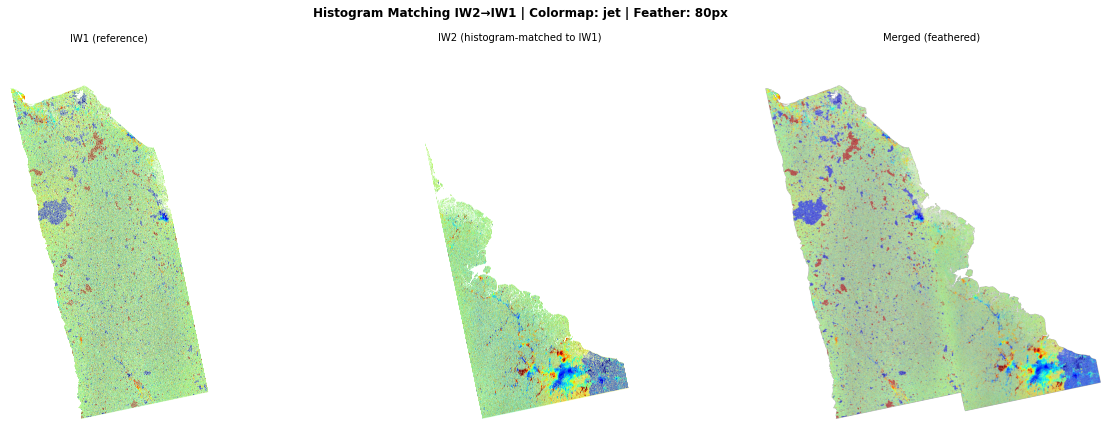

Preview saved: C:\ONSA_InSAR\03_snap_output\S1CIW - deformation_Nov25_Jan26_IW1_IW2_merged_colorized_preview.png


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 0-A │ KMZ COLORIZATION PIPELINE (IW1 + IW2)
# ═══════════════════════════════════════════════════════════
#
# Tujuan: Menggabungkan dua file KMZ (IW1 dan IW2) dari SNAP menjadi
# satu KMZ berwarna dengan transisi yang mulus di area overlap.
#
# ── LIBRARY YANG DIGUNAKAN ──
#   zipfile          → membaca/menulis file .kmz (format ZIP berisi KML + PNG)
#   re               → regex untuk parsing koordinat LatLonBox dari string KML
#   io               → BytesIO: membaca gambar dari memory tanpa tulis ke disk
#   numpy (np)       → operasi array numerik untuk manipulasi piksel raster
#   PIL.Image        → membuka, mengkonversi, dan menyimpan gambar raster
#   matplotlib.plt   → membuat colormap dan colorbar legend
#   matplotlib.colors→ normalisasi nilai untuk colorbar
#   skimage.exposure → fungsi CLAHE (equalize_adapthist) untuk perataan kontras lokal
#
# ── SETTINGS ──
#   KMZ_IW1/IW2     → path file KMZ input dari SNAP (satu per subswath)
#   OUTPUT_KMZ      → path file KMZ output yang sudah digabung dan diwarnai
#   COLORMAP        → skema warna yang diaplikasikan ('jet': biru→hijau→merah)
#   PERCENTILE_LOW/HIGH → potong outlier: abaikan 2% nilai terbawah/teratas
#   CLAHE_LIMIT     → batas kontras CLAHE (0.02 = smooth; lebih besar = lebih kontras)
#   OVERLAP_FEATHER → lebar transisi di tepi tiap swath (piksel), untuk blend halus
#
# ── FUNGSI HELPER ──
#   read_kmz(path)
#     → buka ZIP KMZ, ekstrak: overlay.kml (georef), overlay.png (raster), legend.png
#
#   get_bounds(kml)
#     → parsing koordinat north/south/east/west dari tag <LatLonBox> di KML
#     → dipakai untuk menghitung posisi dan ukuran canvas gabungan
#
#   load_image(img_bytes)
#     → konversi PNG bytes → array grayscale float32
#     → ekstrak alpha channel sebagai mask piksel valid (alpha > 10 = ada data)
#     → Image.MAX_IMAGE_PIXELS = None: nonaktifkan limit ukuran gambar PIL
#
#   percentile_stretch(gray, valid, plow, phigh)
#     → normalisasi array ke rentang 0.0–1.0
#     → hanya pakai piksel valid, buang outlier di luar [plow, phigh] percentile
#     → no-data diisi dengan nilai minimum (vmin) agar tidak mempengaruhi CLAHE
#
#   match_histogram_to_reference(source, source_valid, reference, reference_valid)
#     → KUNCI utama untuk menghilangkan seam/garis batas antar dua swath
#     → teknik: rank-order mapping — petakan distribusi IW2 agar sama dengan IW1
#     → cara kerja: sort kedua distribusi, lalu tiap nilai IW2 diganti dengan
#       nilai IW1 yang memiliki rank (persentil) yang setara
#
#   apply_clahe(norm, clip_limit)
#     → CLAHE = Contrast Limited Adaptive Histogram Equalization
#     → meratakan kontras secara lokal (per tile) agar detail terlihat di semua area
#     → clip sebelum proses: pastikan nilai dalam [0, 1]
#
#   apply_colormap(norm_arr, cmap_name, alpha, valid)
#     → aplikasikan colormap (misal 'jet') ke array 0–1 → RGBA
#     → restore alpha channel asli: piksel no-data tetap transparan
#
# ── PIPELINE EKSEKUSI (Steps 1–12) ──
#   Step 1  → Baca kedua KMZ, ekstrak KML dan PNG bytes
#   Step 2  → Load gambar IW1 dan IW2 sebagai array grayscale
#   Step 3  → Percentile stretch masing-masing swath ke 0–1
#   Step 4  → Histogram matching: samakan distribusi IW2 → IW1
#   Step 5  → Apply CLAHE: IW1 langsung, IW2 dari hasil matched
#   Step 6  → Apply colormap 'jet' → RGBA image per swath
#   Step 7  → Hitung bounding box union kedua swath, resolusi canvas
#   Step 8  → Paste kedua swath ke canvas dengan feathering di tepi
#              (weighted average di area overlap → transisi mulus)
#   Step 9  → Buat string KML untuk georeferencing overlay di Google Earth
#   Step 10 → Buat colorbar legend PNG
#   Step 11 → Simpan sebagai KMZ baru (ZIP: overlay.kml + overlay.png + legend.png)
#   Step 12 → Tampilkan preview perbandingan IW1, IW2, dan hasil merged

import zipfile
import re
import io
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from skimage import exposure

# ══════════════════════════════════════════════════════════════
#  SETTINGS
# ══════════════════════════════════════════════════════════════

KMZ_IW1    = r'C:\ONSA_InSAR\03_snap_output\S1CIW1_Nov25_Jan26.kmz'
KMZ_IW2    = r'C:\ONSA_InSAR\03_snap_output\S1CIW2_Nov25_Jan26.kmz'
OUTPUT_KMZ = r'C:\ONSA_InSAR\03_snap_output\S1CIW - deformation_Nov25_Jan26_IW1_IW2_merged_colorized.kmz'

COLORMAP        = 'jet'
PERCENTILE_LOW  = 2
PERCENTILE_HIGH = 98
CLAHE_LIMIT     = 0.02
OVERLAP_FEATHER = 80

# ══════════════════════════════════════════════════════════════
#  HELPERS
# ══════════════════════════════════════════════════════════════

def read_kmz(path):
    with zipfile.ZipFile(path, 'r') as z:
        kml = z.read('overlay.kml').decode('utf-8')
        img = z.read('overlay.png')
        try:    leg = z.read('legend.png')
        except: leg = None
    return kml, img, leg

def get_bounds(kml):
    return {
        'north': float(re.search(r'<north>(.*?)</north>', kml).group(1)),
        'south': float(re.search(r'<south>(.*?)</south>', kml).group(1)),
        'east' : float(re.search(r'<east>(.*?)</east>',  kml).group(1)),
        'west' : float(re.search(r'<west>(.*?)</west>',  kml).group(1)),
    }

def load_image(img_bytes):
    Image.MAX_IMAGE_PIXELS = None
    img = Image.open(io.BytesIO(img_bytes))
    if img.mode == 'RGBA':
        alpha = np.array(img.split()[3])
    elif img.mode == 'LA':
        alpha = np.array(img.split()[1])
    else:
        alpha = None
    gray  = np.array(img.convert('L'), dtype=np.float32)
    valid = (alpha > 10) if alpha is not None else (gray > 0)
    return gray, alpha, valid

def percentile_stretch(gray, valid, plow, phigh):
    """Stretch ke range 0-1 berdasarkan percentile valid pixels."""
    vals = gray[valid]
    vmin = np.percentile(vals, plow)
    vmax = np.percentile(vals, phigh)
    work = gray.copy()
    work[~valid] = vmin  # fill no-data dengan vmin
    norm = np.clip((work - vmin) / (vmax - vmin + 1e-8), 0.0, 1.0)
    return norm, vmin, vmax

def match_histogram_to_reference(source, source_valid, reference, reference_valid):
    """
    Match distribusi histogram source ke reference.
    Hanya berlaku pada valid pixels.
    Menggunakan rank-order mapping (histogram matching).
    """
    matched = source.copy()

    # Ambil nilai valid dari kedua array
    src_vals = source[source_valid]
    ref_vals = reference[reference_valid]

    # Sort kedua distribusi
    src_sorted = np.sort(src_vals)
    ref_sorted = np.sort(ref_vals)

    # Interpolasi: untuk tiap nilai di source,
    # cari nilai setara di reference berdasarkan rank
    src_ranks = np.searchsorted(src_sorted, src_vals, side='left')
    src_ranks = np.clip(src_ranks, 0, len(src_sorted) - 1)

    # Map rank source → nilai reference
    ref_indices = (src_ranks / len(src_sorted) * (len(ref_sorted) - 1)).astype(int)
    ref_indices = np.clip(ref_indices, 0, len(ref_sorted) - 1)
    matched_vals = ref_sorted[ref_indices]

    matched[source_valid] = matched_vals
    return matched

def apply_clahe(norm, clip_limit):
    """Apply CLAHE pada array 0-1."""
    norm_clipped = np.clip(norm, 0.0, 1.0)
    return exposure.equalize_adapthist(norm_clipped,
                                       clip_limit=clip_limit, nbins=256)

def apply_colormap(norm_arr, cmap_name, alpha, valid):
    cmap       = plt.get_cmap(cmap_name)
    colored    = cmap(norm_arr)
    colored_u8 = (colored * 255).astype(np.uint8)
    if alpha is not None:
        colored_u8[:, :, 3] = alpha
    else:
        colored_u8[~valid, 3] = 0
        colored_u8[valid,  3] = 255
    return colored_u8

# ══════════════════════════════════════════════════════════════
#  STEP 1 — Baca KMZ
# ══════════════════════════════════════════════════════════════

print('Reading KMZ files...')
kml1, img1_bytes, leg1 = read_kmz(KMZ_IW1)
kml2, img2_bytes, leg2 = read_kmz(KMZ_IW2)

b1 = get_bounds(kml1)
b2 = get_bounds(kml2)
print(f'  IW1 bounds: {b1}')
print(f'  IW2 bounds: {b2}')

# ══════════════════════════════════════════════════════════════
#  STEP 2 — Load images
# ══════════════════════════════════════════════════════════════

print('\nLoading images...')
gray1, alpha1, valid1 = load_image(img1_bytes)
gray2, alpha2, valid2 = load_image(img2_bytes)

print(f'  IW1 gray range: [{gray1[valid1].min():.1f}, {gray1[valid1].max():.1f}]')
print(f'  IW2 gray range: [{gray2[valid2].min():.1f}, {gray2[valid2].max():.1f}]')

# ══════════════════════════════════════════════════════════════
#  STEP 3 — Percentile stretch KEDUANYA ke range 0-1
# ══════════════════════════════════════════════════════════════

print('\nPercentile stretching...')
norm1_raw, v1min, v1max = percentile_stretch(gray1, valid1,
                                              PERCENTILE_LOW, PERCENTILE_HIGH)
norm2_raw, v2min, v2max = percentile_stretch(gray2, valid2,
                                              PERCENTILE_LOW, PERCENTILE_HIGH)

print(f'  IW1 stretch: [{v1min:.1f}, {v1max:.1f}]')
print(f'  IW2 stretch: [{v2min:.1f}, {v2max:.1f}]')

# ══════════════════════════════════════════════════════════════
#  STEP 4 — MATCH histogram IW2 → IW1 (kunci utama!)
# ══════════════════════════════════════════════════════════════

print('\nMatching IW2 histogram to IW1...')
norm2_matched = match_histogram_to_reference(
    norm2_raw, valid2,
    norm1_raw, valid1
)

# Statistik sebelum dan sesudah matching untuk verifikasi
print(f'  IW1 norm mean: {norm1_raw[valid1].mean():.4f} | std: {norm1_raw[valid1].std():.4f}')
print(f'  IW2 norm mean (before): {norm2_raw[valid2].mean():.4f} | std: {norm2_raw[valid2].std():.4f}')
print(f'  IW2 norm mean (after) : {norm2_matched[valid2].mean():.4f} | std: {norm2_matched[valid2].std():.4f}')

# ══════════════════════════════════════════════════════════════
#  STEP 5 — Apply CLAHE pada kedua swath (pakai norm yang sudah di-match)
# ══════════════════════════════════════════════════════════════

print('\nApplying CLAHE...')

# IW1: CLAHE langsung
work1 = norm1_raw.copy()
work1[~valid1] = np.median(norm1_raw[valid1])
final1 = apply_clahe(work1, CLAHE_LIMIT)

# IW2: CLAHE pada hasil histogram-matched
work2 = norm2_matched.copy()
work2[~valid2] = np.median(norm2_matched[valid2])
final2 = apply_clahe(work2, CLAHE_LIMIT)

# ══════════════════════════════════════════════════════════════
#  STEP 6 — Apply colormap
# ══════════════════════════════════════════════════════════════

print(f'\nApplying colormap: {COLORMAP}')
colored1 = apply_colormap(final1, COLORMAP, alpha1, valid1)
colored2 = apply_colormap(final2, COLORMAP, alpha2, valid2)

img1_colored = Image.fromarray(colored1, mode='RGBA')
img2_colored = Image.fromarray(colored2, mode='RGBA')
print(f'  IW1 size: {img1_colored.size}')
print(f'  IW2 size: {img2_colored.size}')

# ══════════════════════════════════════════════════════════════
#  STEP 7 — Hitung merged canvas
# ══════════════════════════════════════════════════════════════

print('\nCalculating merged canvas...')
merged_bounds = {
    'north': max(b1['north'], b2['north']),
    'south': min(b1['south'], b2['south']),
    'east' : max(b1['east'],  b2['east']),
    'west' : min(b1['west'],  b2['west']),
}
print(f'  Merged bounds: {merged_bounds}')

total_lon = merged_bounds['east']  - merged_bounds['west']
total_lat = merged_bounds['north'] - merged_bounds['south']

ref_pix_per_deg = max(
    img1_colored.width  / (b1['east'] - b1['west']),
    img2_colored.width  / (b2['east'] - b2['west']),
)
MAX_WIDTH   = 4000
pix_per_deg = min(ref_pix_per_deg, MAX_WIDTH / total_lon)

canvas_w = int(total_lon * pix_per_deg)
canvas_h = int(total_lat * pix_per_deg)
print(f'  Canvas size: {canvas_w} x {canvas_h} px')

# ══════════════════════════════════════════════════════════════
#  STEP 8 — Paste dengan feathering
# ══════════════════════════════════════════════════════════════

print('\nMerging with feathering...')

def geo_to_pixel(bounds, merged, canvas_w, canvas_h, total_lon, total_lat):
    x = int((bounds['west']  - merged['west'])  / total_lon * canvas_w)
    y = int((merged['north'] - bounds['north']) / total_lat * canvas_h)
    w = int((bounds['east']  - bounds['west'])  / total_lon * canvas_w)
    h = int((bounds['north'] - bounds['south']) / total_lat * canvas_h)
    return x, y, max(w,1), max(h,1)

canvas = np.zeros((canvas_h, canvas_w, 4), dtype=np.float32)
weight = np.zeros((canvas_h, canvas_w),    dtype=np.float32)

def paste_with_feather(canvas, weight, img_pil, bounds,
                       merged, canvas_w, canvas_h,
                       total_lon, total_lat, feather_px):
    x, y, w, h = geo_to_pixel(bounds, merged, canvas_w, canvas_h,
                               total_lon, total_lat)
    img_resized = img_pil.resize((w, h), Image.LANCZOS)
    arr = np.array(img_resized, dtype=np.float32)

    wmap = np.ones((h, w), dtype=np.float32)
    for i in range(feather_px):
        val = (i + 1) / (feather_px + 1)
        if i < w: wmap[:, i]     = np.minimum(wmap[:, i], val)
        if i < w: wmap[:, -(i+1)] = np.minimum(wmap[:, -(i+1)], val)
        if i < h: wmap[i, :]     = np.minimum(wmap[i, :], val)
        if i < h: wmap[-(i+1), :] = np.minimum(wmap[-(i+1), :], val)

    valid = arr[:, :, 3] > 10
    wmap[~valid] = 0

    y2 = min(y + h, canvas_h)
    x2 = min(x + w, canvas_w)
    h_  = y2 - y
    w_  = x2 - x

    for c in range(4):
        canvas[y:y2, x:x2, c] += arr[:h_, :w_, c] * wmap[:h_, :w_]
    weight[y:y2, x:x2] += wmap[:h_, :w_]

    print(f'    Pasted at ({x},{y}) size {w}x{h}')

paste_with_feather(canvas, weight, img1_colored, b1,
                   merged_bounds, canvas_w, canvas_h,
                   total_lon, total_lat, OVERLAP_FEATHER)

paste_with_feather(canvas, weight, img2_colored, b2,
                   merged_bounds, canvas_w, canvas_h,
                   total_lon, total_lat, OVERLAP_FEATHER)

print('  Normalizing weighted canvas...')
for c in range(4):
    canvas[:, :, c] = np.where(weight > 0,
                               canvas[:, :, c] / (weight + 1e-8),
                               0)

canvas_u8 = np.clip(canvas, 0, 255).astype(np.uint8)
img_merged = Image.fromarray(canvas_u8, mode='RGBA')

# ══════════════════════════════════════════════════════════════
#  STEP 9 — Build merged KML
# ══════════════════════════════════════════════════════════════

merged_kml = f'''<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://earth.google.com/kml/2.0">
<Document>
  <name>Deformation_IW1_IW2_Jun25_Jan26_Colorized</name>
  <GroundOverlay>
    <name>Raster data</name>
    <LatLonBox>
      <north>{merged_bounds['north']}</north>
      <south>{merged_bounds['south']}</south>
      <east>{merged_bounds['east']}</east>
      <west>{merged_bounds['west']}</west>
    </LatLonBox>
    <Icon><href>overlay.png</href></Icon>
  </GroundOverlay>
  <ScreenOverlay>
    <name>Legend</name>
    <Icon><href>legend.png</href></Icon>
    <overlayXY x="0" y="1" xunits="fraction" yunits="fraction"/>
    <screenXY x="0" y="1" xunits="fraction" yunits="fraction"/>
  </ScreenOverlay>
</Document>
</kml>'''

# ══════════════════════════════════════════════════════════════
#  STEP 10 — Colorbar legend
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(1.2, 4))
fig.subplots_adjust(left=0.05, right=0.4)
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=mcolors.Normalize(0,1), cmap=COLORMAP),
    cax=ax, orientation='vertical'
)
cb.set_label('Unwrapped Phase (normalized)', fontsize=7)
cb.ax.tick_params(labelsize=6)
legend_buf = io.BytesIO()
plt.savefig(legend_buf, format='PNG', dpi=100,
            bbox_inches='tight', transparent=True)
plt.close()
legend_buf.seek(0)

# ══════════════════════════════════════════════════════════════
#  STEP 11 — Simpan KMZ
# ══════════════════════════════════════════════════════════════

print('\nSaving output KMZ...')
img_buf = io.BytesIO()
img_merged.save(img_buf, format='PNG')

with zipfile.ZipFile(OUTPUT_KMZ, 'w', zipfile.ZIP_DEFLATED) as zout:
    zout.writestr('overlay.kml', merged_kml)
    zout.writestr('overlay.png', img_buf.getvalue())
    zout.writestr('legend.png',  legend_buf.read())

print(f'Done! Saved: {OUTPUT_KMZ}')

# ══════════════════════════════════════════════════════════════
#  STEP 12 — Preview
# ══════════════════════════════════════════════════════════════

print('\nGenerating preview...')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img1_colored)
axes[0].set_title('IW1 (reference)', fontsize=10)
axes[0].axis('off')

axes[1].imshow(img2_colored)
axes[1].set_title('IW2 (histogram-matched to IW1)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(img_merged)
axes[2].set_title('Merged (feathered)', fontsize=10)
axes[2].axis('off')

plt.suptitle(f'Histogram Matching IW2→IW1 | Colormap: {COLORMAP} | Feather: {OVERLAP_FEATHER}px',
             fontsize=12, fontweight='bold')
plt.tight_layout()
preview_path = OUTPUT_KMZ.replace('.kmz', '_preview.png')
plt.savefig(preview_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Preview saved: {preview_path}')

In [2]:
# ═══════════════════════════════════════════════════════════
# CELL 0-B │ GEOTIFF MERGE (IW1 + IW2)
# ═══════════════════════════════════════════════════════════
#
# Tujuan: Menggabungkan dua file GeoTIFF (IW1 dan IW2) dari SNAP
# menjadi satu file GeoTIFF merged untuk digunakan di Section 2
# (ekstraksi nilai displacement per titik HM).
#
# ── LIBRARY ──
#   rasterio            → membaca/menulis file GeoTIFF dan raster geospasial
#   rasterio.merge.merge→ fungsi mosaicking: gabungkan beberapa raster jadi satu
#   numpy               → operasi array
#   os                  → cek keberadaan file, hapus file lama sebelum tulis baru
#
# ── SETTINGS ──
#   GEOTIFF_IW1/IW2 → file GeoTIFF Jun25–Nov25 per subswath (dari SNAP export)
#   OUTPUT_TIF      → file GeoTIFF output setelah merge
#
# ── PROSES ──
#   1. Buka kedua GeoTIFF dan tampilkan metadata (CRS, jumlah band, bounds)
#   2. Merge menggunakan dst_path= (tulis LANGSUNG ke disk)
#      → Penting! Tidak melalui RAM — file merged bisa mencapai 5–7 GB
#      → method='first': di area overlap, prioritaskan piksel IW1
#   3. Metadata output: compress LZW (lossless), tiled 256×256 px
#   4. Verifikasi output: bounds, ukuran, jumlah band
#
# ── CATATAN TEKNIS ──
#   Periode yang di-merge di sini: Jun 2025 – Nov 2025 (sesuai nama file)
#   Berbeda dengan Cell 0-A yang path-nya menunjuk Nov25–Jan26
#   → Pastikan path GEOTIFF_IW1/IW2 menunjuk file yang tepat sebelum run

import rasterio
from rasterio.merge import merge
import numpy as np
import os

# ── SETTINGS
GEOTIFF_IW1 = r'C:\ONSA_InSAR\04_geotiff\S1CIW1_Jun25_Nov25.tif'
GEOTIFF_IW2 = r'C:\ONSA_InSAR\04_geotiff\S1CIW2_Jun25_Nov25.tif'
OUTPUT_TIF  = r'C:\ONSA_InSAR\04_geotiff\S1CIW - deformation_Jun25_Nov25_IW1_IW2_merged.tif'

# ── Buka kedua file
src_iw1 = rasterio.open(GEOTIFF_IW1)
src_iw2 = rasterio.open(GEOTIFF_IW2)

print(f'IW1  CRS:    {src_iw1.crs}')
print(f'IW2  CRS:    {src_iw2.crs}')
print(f'IW1  bands:  {src_iw1.count}')
print(f'IW2  bands:  {src_iw2.count}')
print(f'IW1  bounds: {src_iw1.bounds}')
print(f'IW2  bounds: {src_iw2.bounds}')

# ── Merge — urutan prioritas: IW1 > IW2 di area overlap
mosaic, transform = merge(
    [src_iw1, src_iw2],
    method='first'  # piksel file pertama diutamakan di area overlap
)

print(f'\nMosaic shape: {mosaic.shape}')

# ── Salin metadata dari IW1
out_meta = src_iw1.meta.copy()
out_meta.update({
    'driver'   : 'GTiff',
    'height'   : mosaic.shape[1],
    'width'    : mosaic.shape[2],
    'transform': transform,
    'compress' : 'lzw'
})

# ── Simpan merged GeoTIFF
with rasterio.open(OUTPUT_TIF, 'w', **out_meta) as dest:
    dest.write(mosaic)

src_iw1.close()
src_iw2.close()

print(f'\nMerged GeoTIFF saved: {OUTPUT_TIF}')

# ── Verifikasi
with rasterio.open(OUTPUT_TIF) as src:
    print(f'Output bounds: {src.bounds}')
    print(f'Output size  : {src.width} x {src.height} pixels')
    print(f'Output bands : {src.count}')

IW1  CRS:    EPSG:4326
IW2  CRS:    EPSG:4326
IW1  bands:  6
IW2  bands:  6
IW1  bounds: BoundingBox(left=97.04725111540982, bottom=3.471962334577645, right=98.2002665512993, top=5.479997419961874)
IW2  bounds: BoundingBox(left=97.87860890097589, bottom=3.3477209854208727, right=99.02865397596464, top=5.199322644439321)

Mosaic shape: (6, 16908, 15712)

Merged GeoTIFF saved: C:\ONSA_InSAR\04_geotiff\S1CIW - deformation_Jun25_Nov25_IW1_IW2_merged.tif
Output bounds: BoundingBox(left=97.04725111540982, bottom=3.3477448781244976, right=99.02867718220358, top=5.479997419961874)
Output size  : 15712 x 16908 pixels
Output bands : 6


In [3]:
# ═══════════════════════════════════════════════════════════
# CELL 0-C │ KMZ MERGE SEDERHANA (TANPA COLORIZATION)
# ═══════════════════════════════════════════════════════════
#
# Tujuan: Menggabungkan dua KMZ (IW1 + IW2) menjadi satu KMZ
# tanpa proses histogram matching atau CLAHE.
# Berbeda dengan Cell 0-A: tidak ada normalisasi warna —
# hanya menggabungkan geometri (bounds) dan paste gambar.
#
# Cocok digunakan jika:
#   - Kedua swath sudah memiliki distribusi warna yang seragam
#   - Hanya butuh overlay posisi/geometri, bukan perbandingan warna
#
# ── LIBRARY ──
#   zipfile  → baca/tulis file KMZ (format ZIP)
#   re       → parsing koordinat dari KML string
#   os       → operasi file (cek & hapus file lama)
#   io       → BytesIO untuk manipulasi gambar di memory
#   numpy    → array piksel untuk paste dan blend
#   PIL.Image→ resize dan merge gambar raster
#
# ── SETTINGS ──
#   KMZ_IW1/IW2  → file KMZ Jun25–Nov25 per subswath
#   OUTPUT_KMZ   → file KMZ output merged (tanpa suffix '_colorized')
#
# ── FUNGSI YANG DIDEFINISIKAN ──
#   read_kmz(path)        → ekstrak KML + PNG dari ZIP
#   get_bounds(kml)       → parsing koordinat bounding box dari KML
#   (merge langsung)      → hitung canvas gabungan, paste IW1 lalu IW2
#                           dengan alpha blending di area overlap
#   Build KML merged      → tulis ulang tag LatLonBox dengan bounds gabungan
#   Simpan KMZ output     → tulis overlay.kml + overlay.png ke ZIP baru

import zipfile
import re
import os
import io
import numpy as np
from PIL import Image

# ── SETTINGS
KMZ_IW1    = r'C:\ONSA_InSAR\03_snap_output\S1CIW1_Jun25_Nov25.kmz'
KMZ_IW2    = r'C:\ONSA_InSAR\03_snap_output\S1CIW2_Jun25_Nov25.kmz'
OUTPUT_KMZ = r'C:\ONSA_InSAR\03_snap_output\S1CIW - deformation_Jun25_Nov25_IW1_IW2_merged.kmz'

# ── Read KMZ
def read_kmz(path):
    with zipfile.ZipFile(path, 'r') as z:
        kml = z.read('overlay.kml').decode('utf-8')
        img = z.read('overlay.png')
        try:
            leg = z.read('legend.png')
        except:
            leg = None
    return kml, img, leg

kml1, img1, leg1 = read_kmz(KMZ_IW1)
kml2, img2, leg2 = read_kmz(KMZ_IW2)

# ── Extract bounds
def get_bounds(kml):
    return {
        'north': float(re.search(r'<north>(.*?)</north>', kml).group(1)),
        'south': float(re.search(r'<south>(.*?)</south>', kml).group(1)),
        'east' : float(re.search(r'<east>(.*?)</east>',  kml).group(1)),
        'west' : float(re.search(r'<west>(.*?)</west>',  kml).group(1)),
    }

b1 = get_bounds(kml1)
b2 = get_bounds(kml2)

print(f'IW1 bounds: {b1}')
print(f'IW2 bounds: {b2}')

# ── Merged bounds = union of both
merged = {
    'north': max(b1['north'], b2['north']),
    'south': min(b1['south'], b2['south']),
    'east' : max(b1['east'],  b2['east']),
    'west' : min(b1['west'],  b2['west']),
}
print(f'Merged bounds: {merged}')

total_lon = merged['east']  - merged['west']
total_lat = merged['north'] - merged['south']

# ── Open images
Image.MAX_IMAGE_PIXELS = None  # disable decompression bomb check
img1_pil = Image.open(io.BytesIO(img1)).convert('RGBA')
img2_pil = Image.open(io.BytesIO(img2)).convert('RGBA')

print(f'IW1 image size: {img1_pil.size}')
print(f'IW2 image size: {img2_pil.size}')

# ── Calculate canvas size
ref_pix_per_deg = max(
    img1_pil.width / (b1['east'] - b1['west']),
    img2_pil.width / (b2['east'] - b2['west']),
)
# Cap to avoid extremely large canvas
MAX_WIDTH = 4000
pix_per_deg = min(ref_pix_per_deg, MAX_WIDTH / total_lon)

canvas_w = int(total_lon * pix_per_deg)
canvas_h = int(total_lat * pix_per_deg)
print(f'\nCanvas size: {canvas_w} x {canvas_h} px')

canvas = Image.new('RGBA', (canvas_w, canvas_h), (0, 0, 0, 0))

# ── Paste each image at correct geographic position
def geo_to_pixel(bounds, merged, canvas_w, canvas_h):
    """Return (x, y, w, h) of a bounds rect in canvas pixel space."""
    x = int((bounds['west']  - merged['west'])  / total_lon * canvas_w)
    y = int((merged['north'] - bounds['north']) / total_lat * canvas_h)
    w = int((bounds['east']  - bounds['west'])  / total_lon * canvas_w)
    h = int((bounds['north'] - bounds['south']) / total_lat * canvas_h)
    return x, y, w, h

for img_pil, bounds, name in [
    (img1_pil, b1, 'IW1'),
    (img2_pil, b2, 'IW2'),
]:
    x, y, w, h = geo_to_pixel(bounds, merged, canvas_w, canvas_h)
    w = max(w, 1)
    h = max(h, 1)
    img_resized = img_pil.resize((w, h), Image.LANCZOS)
    canvas.paste(img_resized, (x, y), img_resized)  # use alpha mask
    print(f'  {name}: pasted at ({x},{y}) size {w}x{h}')

# ── Build merged KML
merged_kml = f'''<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://earth.google.com/kml/2.0">
<Document>
  <name>Deformation_IW1_IW2_Merged</name>
  <GroundOverlay>
    <name>Raster data</name>
    <LatLonBox>
      <north>{merged['north']}</north>
      <south>{merged['south']}</south>
      <east>{merged['east']}</east>
      <west>{merged['west']}</west>
    </LatLonBox>
    <Icon><href>overlay.png</href></Icon>
  </GroundOverlay>
  <ScreenOverlay>
    <name>Legend</name>
    <Icon><href>legend.png</href></Icon>
    <overlayXY x="0" y="1" xunits="fraction" yunits="fraction"/>
    <screenXY x="0" y="1" xunits="fraction" yunits="fraction"/>
  </ScreenOverlay>
</Document>
</kml>'''

# ── Save merged KMZ
img_buffer = io.BytesIO()
canvas.save(img_buffer, format='PNG')

with zipfile.ZipFile(OUTPUT_KMZ, 'w', zipfile.ZIP_DEFLATED) as zout:
    zout.writestr('overlay.kml', merged_kml)
    zout.writestr('overlay.png', img_buffer.getvalue())
    leg = leg1 or leg2  # use first available legend
    if leg:
        zout.writestr('legend.png', leg)

print(f'\nMerged KMZ saved: {OUTPUT_KMZ}')

# ── Verifikasi
with zipfile.ZipFile(OUTPUT_KMZ, 'r') as z:
    for f in z.infolist():
        print(f'  {f.filename}: {f.file_size/1024**2:.2f} MB')

IW1 bounds: {'north': 5.479997419961874, 'south': 3.471962334577645, 'east': 98.2002665512993, 'west': 97.04725111540982}
IW2 bounds: {'north': 5.199322644439321, 'south': 3.3477209854208727, 'east': 99.02865397596464, 'west': 97.87860890097589}
Merged bounds: {'north': 5.479997419961874, 'south': 3.3477209854208727, 'east': 99.02865397596464, 'west': 97.04725111540982}
IW1 image size: (9143, 15923)
IW2 image size: (8698, 14004)

Canvas size: 4000 x 4304 px
  IW1: pasted at (0,0) size 2327x4053
  IW2: pasted at (1678,566) size 2321x3737

Merged KMZ saved: C:\ONSA_InSAR\03_snap_output\S1CIW - deformation_Jun25_Nov25_IW1_IW2_merged.kmz
  overlay.kml: 0.00 MB
  overlay.png: 25.58 MB
  legend.png: 0.00 MB


---
## 📍 SECTION 1 — Generate Hektometer (HM) Marker Points

Pipeline ONSA memiliki titik referensi operasional setiap 100 meter yang disebut
**Hektometer Marker (HM)**. Section ini membuat semua titik HM secara otomatis
dari file KMZ jalur pipa, dengan jarak tepat 100 m sepanjang garis.

Dengan pipa sepanjang ±334 km → dihasilkan ±3.347 titik HM.

**Output:** file CSV dan Shapefile berisi koordinat semua titik HM,
dipakai sebagai input di Section 2 untuk sampling nilai deformasi.


In [4]:
# ═══════════════════════════════════════════════════════════
# CELL 1-A │ INSTALASI LIBRARY
# ═══════════════════════════════════════════════════════════
#
# Jalankan cell ini SEKALI saja saat pertama kali setup environment.
# Setelah terinstall, tidak perlu dijalankan lagi.
#
# Library yang diinstall:
#   rasterio  → baca GeoTIFF dan raster geospasial
#   geopandas → baca/tulis Shapefile, KMZ, GeoJSON
#   pandas    → manipulasi tabel dan CSV
#   numpy     → operasi array numerik
#   openpyxl  → tulis file Excel (.xlsx)
#   pyproj    → transformasi koordinat (WGS84 ↔ UTM)
#   matplotlib→ visualisasi (grafik, plot)
#   shapely   → operasi geometri (LineString, Point, interpolasi)
#
# subprocess.check_call() → jalankan pip install dari dalam Python
# sys.executable          → pastikan install ke Python yang sedang aktif

# Run this cell ONCE to install all required Python libraries
# After installing, you never need to run this cell again
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
'rasterio', 'geopandas', 'pandas', 'numpy',
'openpyxl', 'pyproj', 'matplotlib', 'shapely'])

0

In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 1-B │ IMPORT LIBRARY
# ═══════════════════════════════════════════════════════════
#
# Library:
#   geopandas (gpd)       → membaca file geospasial (KMZ/KML, Shapefile)
#                           mengelola GeoDataFrame (DataFrame + geometri)
#   pandas (pd)           → membuat dan menyimpan tabel data (DataFrame, CSV)
#   numpy (np)            → np.arange() untuk membuat array jarak interpolasi
#   shapely.geometry.Point→ membuat objek titik (koordinat tunggal)
#   shapely.ops.transform → transformasi koordinat pada objek shapely
#   shapely.ops.linemerge → menggabungkan segmen-segmen LineString yang tersambung
#                           menjadi satu LineString kontinu
#   pyproj                → mendefinisikan transformasi CRS (misal WGS84→UTM)

# Import all libraries we will use in this notebook
import geopandas as gpd # geographic data (like shapefile, KMZ)
import pandas as pd # tables and CSV files
import numpy as np # math operations
from shapely.geometry import Point # creates GPS point objects
from shapely.ops import transform, linemerge # geometry tools
import pyproj # coordinate system conversion
print('All libraries loaded successfully!')

C:\Users\ASUS\anaconda4\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ASUS\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


All libraries loaded successfully!


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 1-C │ KONFIGURASI PATH DAN PARAMETER
# ═══════════════════════════════════════════════════════════
#
# Sesuaikan semua path dan parameter berikut sebelum menjalankan:
#
#   KMZ_PATH       → file KMZ jalur pipa ONSA (berisi 3 segmen: Arun-RPA, RPA-PBR, PBR-BLW)
#   PIPELINE_LAYER → nama layer di dalam KMZ yang berisi geometri garis pipa
#                    gunakan Cell 1-E untuk melihat daftar layer yang tersedia
#   OUT_SHP        → path output Shapefile titik HM (untuk digunakan di QGIS)
#   OUT_CSV        → path output CSV titik HM (untuk digunakan di Section 2)
#   HM_SPACING     → jarak antar titik HM dalam meter
#                    default: 100 m = 1 titik per HM (sesuai standar operasional ONSA)

KMZ_PATH      = r'C:\ONSA_InSAR\02_pipeline\Data Jalur ONSA September 2025.kmz'
PIPELINE_LAYER = 'Ruas Arbel (All)'   # ← add this line
OUT_SHP        = r'C:\ONSA_InSAR\02_pipeline\pipeline_hm.shp'
OUT_CSV        = r'C:\ONSA_InSAR\05_csv_output\pipeline_hm.csv'
HM_SPACING     = 100

In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 1-D │ BACA FILE KMZ JALUR PIPA (SATU LAYER)
# ═══════════════════════════════════════════════════════════
#
# gpd.read_file() → membaca satu layer dari file KMZ
#
# Path '/vsizip/{KMZ_PATH}/doc.kml':
#   '/vsizip/' → virtual filesystem handler dari GDAL untuk membaca isi ZIP
#   '{...}'    → path file KMZ di dalam handler
#   '/doc.kml' → file KML utama di dalam KMZ
#
# layer=PIPELINE_LAYER → pilih layer yang berisi garis pipa
# driver='KML'         → gunakan GDAL KML driver untuk parsing
#
# Output: GeoDataFrame berisi geometri jalur pipa sebagai LineString
# gdf.head(100) → tampilkan 100 baris pertama untuk verifikasi

gdf = gpd.read_file(
    '/vsizip/{' + KMZ_PATH + '}/doc.kml',
    layer=PIPELINE_LAYER,
    driver='KML'
)

print(f'Number of features: {len(gdf)}')
print(f'Geometry types: {gdf.geometry.type.unique()}')
print(f'Coordinate system: {gdf.crs}')
gdf.head(100)

Number of features: 3
Geometry types: ['LineString']
Coordinate system: EPSG:4326


,Name,Description,geometry
0,ARUN - BELAWAN [Arun-RPA],ARUN - BELAWAN <br> <br> SEGMEN A...,"LINESTRING Z (97.79526 4.76339 0, 97.79524 4.7..."
1,ARUN - BELAWAN [RPA-PBR],ARUN - BELAWAN <br> <br> SEGMEN A...,"LINESTRING Z (98.27582 4.01685 0, 98.27579 4.0..."
2,ARUN - BELAWAN [PBR-BLW],ARUN - BELAWAN <br> <br> SEGMEN A...,"LINESTRING Z (98.67141 3.77211 0, 98.6714 3.77..."


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 1-E │ INSPEKSI SEMUA LAYER DI KMZ
# ═══════════════════════════════════════════════════════════
#
# pyogrio → library I/O geospasial yang lebih cepat dari fiona
# pyogrio.list_layers() → tampilkan semua layer yang ada di KMZ
#                         tanpa perlu membaca seluruh datanya
#
# Berguna untuk mengetahui nama layer yang tepat sebelum membaca
# dengan gpd.read_file(). File KMZ pipa ONSA biasanya berisi
# beberapa layer (satu per segmen operasional: Arun-RPA, RPA-PBR, PBR-BLW)
# plus layer tambahan seperti waypoint atau label.
#
# Salin nama layer yang sesuai ke variabel PIPELINE_LAYER di Cell 1-C.

import pyogrio

layers = pyogrio.list_layers(f'/vsizip/{{{KMZ_PATH}}}/doc.kml')
print(f'Total layers: {len(layers)}')
print()
for i, (name, geom_type) in enumerate(layers):
    print(f'[{i:2d}] {geom_type:20s} {name}')

Total layers: 76

[ 0] Point Z              Future Connection
[ 1] Unknown              Konsumen KEK
[ 2] LineString Z         Ruas Arbel (All)
[ 3] LineString Z         BEL-KIM
[ 4] LineString Z         HDD Tongguran
[ 5] LineString Z         MKTT
[ 6] LineString Z         KIM-KEK
[ 7] LineString Z         TK-KT
[ 8] MultiLineString Z    Aceh
[ 9] LineString Z         Sumut
[10] Unknown              Arbel
[11] Point Z              BEL-KIM-KEK-KT
[12] Unknown              Sumut (#2)
[13] Point Z              Sumut (#3)
[14] Unknown              LBCV
[15] Unknown              MLBV
[16] Unknown              Box Valve
[17] Point Z              Konsumen KEK (#2)
[18] Point Z              TK-KT (#2)
[19] Point Z              Arbel (#2)
[20] Point Z              Patok KP KIM-KEK
[21] Point Z              Patok KP BEL-KIM
[22] Point Z              Patok KP TK-KT
[23] Point Z              Patok KP Konsumen KEK
[24] Point Z              Sumut (#4)
[25] Point Z              Test Point Ruas Arbel

In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 1-F │ BACA SEMUA LAYER DAN IDENTIFIKASI SEGMEN PIPA
# ═══════════════════════════════════════════════════════════
#
# Membaca setiap layer satu per satu dari KMZ dan mencatat:
#   - Jumlah fitur per layer
#   - Tipe geometri (LineString, Point, Polygon, dll)
#   - Nama layer
#
# Layer yang relevan untuk HM generation adalah yang
# bertipe LineString (garis pipa), bukan Point atau Polygon.
#
# Setiap layer dibaca dengan try-except untuk menangani layer
# yang mungkin tidak bisa dibaca (format tidak kompatibel).
#
# Hasil tampilan ini membantu memilih layer mana yang harus
# dipakai sebagai PIPELINE_LAYER di Cell 1-C.

import pyogrio

# Get all layer names from the KMZ
all_layers = pyogrio.list_layers('/vsizip/{' + KMZ_PATH + '}/doc.kml')

print(f'Total layers found: {len(all_layers)}')
print('-' * 60)

# Test every single layer
for name, _ in all_layers:
    try:
        test = gpd.read_file(
            '/vsizip/{' + KMZ_PATH + '}/doc.kml',
            layer=name,
            driver='KML'
        )
        geom_types = test.geometry.type.unique().tolist()
        n = len(test)
        print(f"[{n:4d} features] [{str(geom_types):30s}] {name}")
    except Exception as e:
        print(f"[SKIP              ] {name}")

Total layers found: 76
------------------------------------------------------------
[  14 features] [['Point']                     ] Future Connection
[   6 features] [['LineString']                ] Konsumen KEK
[   3 features] [['LineString']                ] Ruas Arbel (All)
[   3 features] [['LineString']                ] BEL-KIM
[   1 features] [['LineString']                ] HDD Tongguran
[   5 features] [['LineString']                ] MKTT
[   1 features] [['LineString']                ] KIM-KEK
[   4 features] [['LineString']                ] TK-KT
[   3 features] [['MultiLineString']           ] Aceh
[   2 features] [['LineString']                ] Sumut
[   8 features] [['Point', 'Polygon']          ] Arbel
[  12 features] [['Point']                     ] BEL-KIM-KEK-KT
[   6 features] [['Point', 'Polygon']          ] Sumut (#2)
[   4 features] [['Point']                     ] Sumut (#3)
[  34 features] [['Point', 'Polygon']          ] LBCV
[   8 features] [['Polygon', 'Poi

In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 1-G │ GABUNG SEGMEN PIPA — METODE 1 (UNARY_UNION + LINEMERGE)
# ═══════════════════════════════════════════════════════════
#
# Jalur pipa Arun–Belawan terbagi menjadi 3 segmen di KMZ.
# Untuk membuat titik HM yang kontinu, semua segmen harus
# digabung menjadi SATU LineString tunggal.
#
# unary_union(gdf.geometry)
#   → gabungkan semua geometri dalam GeoDataFrame menjadi satu objek
#   → hasilnya MultiLineString (beberapa garis yang belum disambung)
#
# linemerge(combined)
#   → sambungkan segmen-segmen yang endpoint-nya saling bertemu
#   → jika berhasil: hasil berupa LineString tunggal
#   → jika gagal (ada gap): hasil tetap MultiLineString
#
# Setelah merge, proyeksikan ke UTM untuk mengukur panjang dalam meter:
#   .to_crs('EPSG:32647') → UTM Zone 47N (mencakup Sumatera Utara–Aceh)
#   line_utm.length       → panjang total pipa dalam meter (~334.000 m)

from shapely.ops import linemerge, unary_union

# Combine all 3 segments into one geometry
combined = unary_union(gdf.geometry)

# Merge into single continuous LineString
line = linemerge(combined)

print(f'Geometry type after merge: {line.geom_type}')

# Measure total length
line_utm = gpd.GeoSeries([line], crs='EPSG:4326').to_crs('EPSG:32647').iloc[0]
print(f'Total pipeline length: {line_utm.length/1000:.2f} km')


Geometry type after merge: MultiLineString
Total pipeline length: 334.70 km


In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 1-H │ DEBUG: CEK GAP ANTAR SEGMEN
# ═══════════════════════════════════════════════════════════
#
# Cell ini dijalankan jika Cell 1-G menghasilkan MultiLineString
# (gagal linemerge karena ada gap antara endpoint segmen).
#
# Proses debug:
#   1. combined.geoms → pecah menjadi segmen-segmen individual
#   2. Konversi ke UTM agar jarak bisa diukur dalam meter
#   3. Ambil koordinat start dan end tiap segmen
#   4. Hitung jarak (gap) antara end segmen ke start segmen berikutnya
#
# Jika gap < 1 m: bisa ditoleransi, cukup chain koordinat langsung
# Jika gap > 1 m: perlu periksa data KMZ (mungkin ada segmen yang salah arah
#                 atau ada koordinat yang tidak tepat di endpoint)
#
# Informasi ini dipakai untuk memilih metode merge di Cell 1-I dan 1-J.

from shapely.ops import linemerge, unary_union
from shapely.geometry import LineString
import numpy as np

# ── STEP 1: See where the gaps are
combined = unary_union(gdf.geometry)
geoms = list(combined.geoms)  # get individual segments

print(f'Number of segments: {len(geoms)}')
print()

# Convert each segment to UTM and check endpoints
for i, seg in enumerate(geoms):
    seg_utm = gpd.GeoSeries([seg], crs='EPSG:4326').to_crs('EPSG:32647').iloc[0]
    start = list(seg_utm.coords)[0]
    end   = list(seg_utm.coords)[-1]
    print(f'Segment {i}: {seg_utm.length/1000:.2f} km')
    print(f'  Start: ({start[0]:.1f}, {start[1]:.1f})')
    print(f'  End:   ({end[0]:.1f},   {end[1]:.1f})')
    print()

# ── STEP 2: Force-connect segments by snapping endpoints
# Sort segments by their start X coordinate (west to east)
segs_utm = [
    gpd.GeoSeries([seg], crs='EPSG:4326').to_crs('EPSG:32647').iloc[0]
    for seg in geoms
]
segs_utm.sort(key=lambda s: list(s.coords)[0][0])

# Build one continuous coordinate list by bridging gaps
all_coords = []
for i, seg in enumerate(segs_utm):
    coords = list(seg.coords)
    if i == 0:
        all_coords.extend(coords)
    else:
        # Add the end of previous segment to start of this one
        # to bridge any small gap
        all_coords.extend(coords)

# Create single LineString from all coordinates
line = LineString(all_coords)

# Convert back to WGS84
line_wgs84 = gpd.GeoSeries(
    [line], crs='EPSG:32647'
).to_crs('EPSG:4326').iloc[0]

print(f'Result geometry type: {line_wgs84.geom_type}')
print(f'Total length: {line.length/1000:.2f} km')
print('Pipeline merged successfully!' if line_wgs84.geom_type == 'LineString' else 'Still fragmented')

# Use this as your final line variable
line = line_wgs84


Number of segments: 23

Segment 0: 127.90 km
  Start: (366392.5, 526626.9)
  End:   (286932.6,   577473.8)

Segment 1: 34.87 km
  Start: (419611.1, 444025.1)
  End:   (397372.2,   456841.8)

Segment 2: 0.02 km
  Start: (397372.2, 456841.8)
  End:   (397372.2,   456841.8)

Segment 3: 4.26 km
  Start: (397372.2, 456841.8)
  End:   (395140.8,   459940.5)

Segment 4: 0.01 km
  Start: (395140.8, 459940.5)
  End:   (395140.8,   459940.5)

Segment 5: 6.26 km
  Start: (395140.8, 459940.5)
  End:   (393416.0,   465545.7)

Segment 6: 0.01 km
  Start: (393416.0, 465545.7)
  End:   (393416.0,   465545.7)

Segment 7: 2.60 km
  Start: (393416.0, 465545.7)
  End:   (395322.4,   467212.7)

Segment 8: 0.02 km
  Start: (395322.4, 467212.7)
  End:   (395322.4,   467212.7)

Segment 9: 77.35 km
  Start: (395322.4, 467212.7)
  End:   (370817.7,   518306.8)

Segment 10: 0.01 km
  Start: (370817.7, 518306.8)
  End:   (370817.7,   518306.8)

Segment 11: 10.75 km
  Start: (370817.7, 518306.8)
  End:   (366407.5

In [14]:
# ═══════════════════════════════════════════════════════════
# CELL 1-I │ HANDLE MULTILINESTRING DALAM SATU ROW GDF
# ═══════════════════════════════════════════════════════════
#
# Kasus: ada baris di GeoDataFrame yang geometrinya sudah MultiLineString
# (bukan LineString tunggal) dalam satu row — artinya satu segmen operasional
# tersimpan sebagai beberapa sub-segmen.
#
# line = gdf.geometry.iloc[0]
#   → ambil geometri dari baris pertama GeoDataFrame
#
# if line.geom_type == 'MultiLineString':
#   linemerge(line) → coba gabungkan sub-segmen menjadi satu LineString
#
# Jika berhasil: lanjut ke Cell 1-K untuk interpolasi HM
# Jika masih MultiLineString: gunakan Cell 1-J (manual chain)

line = gdf.geometry.iloc[0]
# If the pipeline is stored as multiple segments (MultiLineString),
# merge them into one continuous line
if line.geom_type == 'MultiLineString':
    line = linemerge(line)
    print('MultiLineString merged into single LineString')
else:
    print('Single LineString — no merging needed')
    print(f'Pipeline geometry type: {line.geom_type}')

Single LineString — no merging needed
Pipeline geometry type: LineString


In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 1-J │ GABUNG 3 SEGMEN PIPA — METODE FINAL (VERIFIED)
# ═══════════════════════════════════════════════════════════
#
# Metode ini bekerja langsung dengan 3 segmen yang ada di GeoDataFrame
# tanpa perlu unary_union, karena gdf sudah berisi tepat 3 row (3 segmen).
#
# Proses:
#   1. Iterasi 3 row di gdf → tampilkan panjang tiap segmen (verifikasi)
#   2. unary_union(gdf.geometry) → gabungkan 3 geometri
#   3. linemerge(multi) → sambungkan jadi satu LineString
#
# Setelah merge:
#   to_crs('EPSG:32647') → proyeksi ke UTM Zone 47N untuk pengukuran meter
#   line_utm.length      → verifikasi panjang total (~334.000 m)
#
# Definisi transformer untuk konversi balik UTM → WGS84:
#   pyproj.Transformer.from_crs('EPSG:32647','EPSG:4326', always_xy=True)
#   to_wgs84 = transformer.transform
#   → dipakai di Cell 1-K untuk mengonversi koordinat titik HM kembali ke lat/lon

from shapely.ops import linemerge, unary_union
from shapely.geometry import LineString

# ── Work directly with the 3 clean segments from gdf
# No unary_union needed — gdf already has exactly the right segments
print('Segments in layer:')
for i, row in gdf.iterrows():
    seg_u = gpd.GeoSeries(
        [row.geometry], crs='EPSG:4326'
    ).to_crs('EPSG:32647').iloc[0]
    print(f'  Segment {i}: {seg_u.length/1000:.2f} km  |  {row["Name"]}')

# ── Merge the 3 segments into one continuous LineString
multi = unary_union(gdf.geometry)  # combine geometries
line  = linemerge(multi)           # stitch end-to-end

print(f'\nAfter merge: {line.geom_type}')

# ── Convert to UTM for accurate metre-based measurement
wgs84    = pyproj.CRS('EPSG:4326')
utm      = pyproj.CRS('EPSG:32647')
to_utm   = pyproj.Transformer.from_crs(wgs84, utm,   always_xy=True).transform
to_wgs84 = pyproj.Transformer.from_crs(utm,   wgs84, always_xy=True).transform

line_utm = transform(to_utm, line)

print(f'Pipeline length: {line_utm.length/1000:.2f} km')
print(f'Expected HM markers: ~{int(line_utm.length/100)} points')


Segments in layer:
  Segment 0: 127.90 km  |  ARUN - BELAWAN [Arun-RPA]
  Segment 1: 136.16 km  |  ARUN - BELAWAN [RPA-PBR]
  Segment 2: 70.64 km  |  ARUN - BELAWAN [PBR-BLW]

After merge: MultiLineString
Pipeline length: 334.70 km
Expected HM markers: ~3347 points


In [16]:
# ═══════════════════════════════════════════════════════════
# CELL 1-K │ CHAIN MANUAL 3 SEGMEN BERDASARKAN NAMA + ARAH
# ═══════════════════════════════════════════════════════════
#
# Digunakan jika linemerge() gagal karena segmen tersimpan dengan arah
# yang terbalik (East→West) sedangkan kita butuh West→East (Arun→Belawan).
#
# Proses:
#   1. Baca 3 segmen berdasarkan kolom 'Name' di GeoDataFrame
#   2. Konversi ke UTM, ambil list koordinat tiap segmen
#   3. Reverse (balik urutan) tiap segmen agar arahnya Arun→Belawan
#   4. Chain (sambung) dengan skip koordinat pertama seg2 dan seg3
#      untuk menghindari duplikasi titik di junction
#
# Nama segmen ONSA:
#   'ARUN - BELAWAN [Arun-RPA]'   → segmen 1: Arun ke SKG Rantau Panjang
#   'ARUN - BELAWAN [RPA-PBR]'   → segmen 2: SKG Rantau Panjang ke Pangkalan Brandan
#   'ARUN - BELAWAN [PBR-BLW]'   → segmen 3: Pangkalan Brandan ke Belawan
#
# LineString(seg1 + seg2[1:] + seg3[1:])
#   → gabungkan koordinat langsung (tanpa gap) → satu LineString utuh
# .to_crs('EPSG:32647') → proyeksi UTM untuk interpolasi dalam meter

from shapely.geometry import LineString

# ── Load all 3 segments
segs = {}
for _, row in gdf.iterrows():
    seg_utm = gpd.GeoSeries(
        [row.geometry], crs='EPSG:4326'
    ).to_crs('EPSG:32647').iloc[0]
    segs[row['Name']] = list(seg_utm.coords)

# ── Reverse all 3 (stored East→West, we need West→East)
# ── Chain in correct order: Arun-RPA → RPA-PBR → PBR-BLW
seg1 = list(reversed(segs['ARUN - BELAWAN [Arun-RPA]']))
seg2 = list(reversed(segs['ARUN - BELAWAN [RPA-PBR]']))
seg3 = list(reversed(segs['ARUN - BELAWAN [PBR-BLW]']))

# ── Concatenate — skip first coord of seg2 and seg3 to avoid duplicates
all_coords = seg1 + seg2[1:] + seg3[1:]

# ── Build final LineString
line_utm = LineString(all_coords)

# ── Verify
coords = list(line_utm.coords)
print(f'Length:    {line_utm.length/1000:.2f} km')
print(f'Start X:   {coords[0][0]:.0f}  (Arun west ~286933)')
print(f'End X:     {coords[-1][0]:.0f}  (Belawan east ~463514)')
print(f'West→East: {coords[0][0] < coords[-1][0]} ✅')

# ── Update WGS84 line
line = gpd.GeoSeries(
    [line_utm], crs='EPSG:32647'
).to_crs('EPSG:4326').iloc[0]

# ── Verify longitude increases steadily
print()
print('Longitude check (must increase):')
for d in [0, 50000, 100000, 150000, 200000, 250000, 300000,
          int(line_utm.length)]:
    pt = line_utm.interpolate(min(d, line_utm.length))
    pt_wgs = gpd.GeoSeries(
        [pt], crs='EPSG:32647'
    ).to_crs('EPSG:4326').iloc[0]
    print(f'  KP {d/1000:5.0f} km: lon={pt_wgs.x:.4f}')

Length:    334.73 km
Start X:   286933  (Arun west ~286933)
End X:     463514  (Belawan east ~463514)
West→East: True ✅

Longitude check (must increase):
  KP     0 km: lon=97.0776
  KP    50 km: lon=97.3476
  KP   100 km: lon=97.6642
  KP   150 km: lon=97.8664
  KP   200 km: lon=98.0841
  KP   250 km: lon=98.1859
  KP   300 km: lon=98.4228
  KP   335 km: lon=98.6714


In [17]:
# ═══════════════════════════════════════════════════════════
# CELL 1-L │ INTERPOLASI TITIK HM SETIAP 100 METER
# ═══════════════════════════════════════════════════════════
#
# Ini adalah cell inti Section 1 — menghasilkan semua titik HM.
#
# np.arange(0, line_utm.length, HM_SPACING)
#   → array jarak [0, 100, 200, ..., ~334000] dalam meter
#   → contoh: pipa 334 km → 3.340 nilai jarak
#
# line_utm.interpolate(d)
#   → kembalikan Point yang berada tepat pada jarak d meter
#     sepanjang LineString (dalam koordinat UTM)
#
# transform(to_wgs84, pt_utm)
#   → konversi titik UTM balik ke WGS84 (lat/lon)
#   → to_wgs84 adalah fungsi transformer dari Cell 1-J
#
# Setiap titik disimpan sebagai dictionary dengan kolom:
#   HM_ID    : nomor urut integer (0, 1, 2, ..., 3346)
#   HM_LABEL : label string format 'HM0000', 'HM0001', ...
#   KP       : posisi dalam kilometer (0.0, 0.1, 0.2, ...)
#   lon, lat : koordinat WGS84 (longitude, latitude)
#   geometry : objek Point untuk disimpan ke Shapefile
#
# Verifikasi: tampilkan longitude setiap 300 titik
#   → longitude harus meningkat monoton (West→East: Arun~97° → Belawan~98.6°)
#   → jika ada nilai yang turun/tidak urut, ada masalah arah segmen

distances = np.arange(0, line_utm.length, HM_SPACING)
records   = []

for i, d in enumerate(distances):
    pt_utm   = line_utm.interpolate(d)
    pt_wgs84 = transform(to_wgs84, pt_utm)
    records.append({
        'HM_ID'   : i,
        'HM_LABEL': f'HM{i:04d}',
        'KP'      : round(d/1000, 3),
        'lon'     : round(pt_wgs84.x, 6),
        'lat'     : round(pt_wgs84.y, 6),
        'geometry': pt_wgs84
    })

# Verify BEFORE saving
print('Verification — longitude must increase steadily:')
for i in range(0, len(records), 300):
    print(f'  HM{records[i]["HM_ID"]:04d}: lon={records[i]["lon"]:.4f}')

Verification — longitude must increase steadily:
  HM0000: lon=97.0776
  HM0300: lon=97.2522
  HM0600: lon=97.4190
  HM0900: lon=97.6086
  HM1200: lon=97.7677
  HM1500: lon=97.8664
  HM1800: lon=97.9502
  HM2100: lon=98.0611
  HM2400: lon=98.1148
  HM2700: lon=98.2786
  HM3000: lon=98.4228
  HM3300: lon=98.6499


In [18]:
# ═══════════════════════════════════════════════════════════
# CELL 1-M │ PREVIEW PETA HM POINTS (VERIFIKASI VISUAL)
# ═══════════════════════════════════════════════════════════
#
# folium → library Python untuk membuat peta interaktif Leaflet.js
#          output berupa HTML yang ditampilkan langsung di Jupyter
#
# folium.Map() → buat peta dengan center di rata-rata lat/lon semua HM
#
# folium.PolyLine() → gambar garis biru sepanjang jalur pipa
#   locations=zip(lat,lon): koordinat semua titik HM
#   color='steelblue', weight=2: garis tipis biru
#
# Marker setiap 10 km (HM_ID % 100 == 0):
#   → 100 HM = 10 km, jadi tampilkan marker di setiap kelipatan 100
#   → tooltip menampilkan label HM dan posisi KP saat hover
#
# Jalankan cell ini untuk verifikasi visual:
#   ✅ Garis mengikuti jalur pipa dari Arun (barat laut) ke Belawan (tenggara)
#   ✅ Longitude meningkat dari kiri ke kanan
#   ✅ Tidak ada lompatan/gap di sepanjang jalur

import folium

# Use records directly from memory — already verified correct
df = pd.DataFrame(records)

m = folium.Map(
    location=[df['lat'].mean(), df['lon'].mean()],
    zoom_start=9,
    tiles='OpenStreetMap'
)

# Pipeline line
folium.PolyLine(
    locations=list(zip(df['lat'], df['lon'])),
    color='steelblue', weight=2, opacity=0.8,
    tooltip='ONSA Pipeline RoW'
).add_to(m)

# Every 10 km marker
for _, row in df[df['HM_ID'] % 100 == 0].iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        tooltip=f"{row['HM_LABEL']}  |  KP {row['KP']:.1f} km",
        icon=folium.Icon(color='red', icon='flag', prefix='fa')
    ).add_to(m)

# Start and end
folium.Marker(
    [df.iloc[0]['lat'], df.iloc[0]['lon']],
    tooltip='START — Arun (HM0000)',
    icon=folium.Icon(color='green', icon='star', prefix='fa')
).add_to(m)

folium.Marker(
    [df.iloc[-1]['lat'], df.iloc[-1]['lon']],
    tooltip='END — Belawan (HM3347)',
    icon=folium.Icon(color='blue', icon='star', prefix='fa')
).add_to(m)

OUTPUT_MAP = r'C:\ONSA_InSAR\06_qgis\pipeline_map.html'
m.save(OUTPUT_MAP)
print(f'Map saved: {OUTPUT_MAP}')

Map saved: C:\ONSA_InSAR\06_qgis\pipeline_map.html


In [19]:
# ═══════════════════════════════════════════════════════════
# CELL 1-N │ SIMPAN HM POINTS KE FILE CSV
# ═══════════════════════════════════════════════════════════
#
# pd.DataFrame(records) → konversi list dictionary ke DataFrame
# .drop(columns=['geometry']) → hapus kolom geometry (tidak bisa disimpan ke CSV)
#
# df_save.to_csv(CORRECT_CSV, index=False)
#   → simpan ke CSV tanpa kolom index default pandas
#
# Verifikasi setelah simpan:
#   → baca ulang file CSV yang baru disimpan
#   → tampilkan longitude setiap 300 baris untuk konfirmasi arah tidak berubah
#
# File CSV ini dipakai sebagai input di:
#   → Section 2: matching HM ke nilai deformasi GeoTIFF
#   → Section 4: data koordinat untuk dashboard peta
#
# Kolom output CSV: HM_ID, HM_LABEL, KP, lon, lat

# Save correct records to CSV — overwrite the old file
df_hm = pd.DataFrame(records)
df_save = df_hm.drop(columns=['geometry'])

CORRECT_CSV = r'C:\ONSA_InSAR\05_csv_output\pipeline_hm_corrected.csv'
df_save.to_csv(CORRECT_CSV, index=False)
print(f'CSV updated: {CORRECT_CSV}')
print(f'Total rows: {len(df_save)}')

# Verify
df_check = pd.read_csv(CORRECT_CSV)
print()
print('Verification:')
for i in range(0, len(df_check), 300):
    print(f'  Row {i:4d}: lon={df_check.iloc[i]["lon"]:.4f}')

CSV updated: C:\ONSA_InSAR\05_csv_output\pipeline_hm_corrected.csv
Total rows: 3348

Verification:
  Row    0: lon=97.0776
  Row  300: lon=97.2522
  Row  600: lon=97.4190
  Row  900: lon=97.6086
  Row 1200: lon=97.7677
  Row 1500: lon=97.8664
  Row 1800: lon=97.9502
  Row 2100: lon=98.0611
  Row 2400: lon=98.1148
  Row 2700: lon=98.2786
  Row 3000: lon=98.4228
  Row 3300: lon=98.6499


In [20]:
# ═══════════════════════════════════════════════════════════
# CELL 1-O │ SIMPAN HM POINTS KE SHAPEFILE
# ═══════════════════════════════════════════════════════════
#
# gpd.GeoDataFrame(records, geometry='geometry', crs='EPSG:4326')
#   → buat GeoDataFrame dari records dengan kolom 'geometry' sebagai geometri aktif
#   → CRS: WGS84 (EPSG:4326) — sistem koordinat standar lat/lon
#
# .to_file(CORRECT_SHP)
#   → simpan ke format Shapefile (.shp + .dbf + .shx + .prj)
#   → Shapefile adalah format GIS standar, bisa dibuka di QGIS/ArcGIS
#
# Verifikasi: tampilkan longitude titik pertama dan terakhir
#   → HM0000: seharusnya sekitar 97.0° (Arun, Aceh)
#   → HM3347: seharusnya sekitar 98.6° (Belawan, Medan)
#
# Shapefile ini dipakai di Section 2 sebagai input HM_SHP
# untuk proses point sampling nilai displacement dari GeoTIFF.

# Rebuild shapefile from correct records
CORRECT_SHP = r'C:\ONSA_InSAR\02_pipeline\pipeline_hm_corrected.shp'

gdf_out = gpd.GeoDataFrame(records, geometry='geometry', crs='EPSG:4326')
gdf_out.to_file(CORRECT_SHP)

print(f'Shapefile saved: {CORRECT_SHP}')
print(f'Total markers:   {len(records)}')
print(f'Verification:')
print(f'  HM0000: lon={records[0]["lon"]:.4f}')
print(f'  HM3347: lon={records[-1]["lon"]:.4f}')

Shapefile saved: C:\ONSA_InSAR\02_pipeline\pipeline_hm_corrected.shp
Total markers:   3348
Verification:
  HM0000: lon=97.0776
  HM3347: lon=98.6714


---
## 📊 SECTION 2 — Extract Deformation Values per HM Point

GeoTIFF hasil DInSAR dari SNAP berisi nilai displacement (deformasi) dalam meter
untuk setiap piksel raster. Section ini melakukan **point sampling**:
mengekstrak nilai displacement dari GeoTIFF ke setiap titik HM
menggunakan buffer 100 m dan mengambil median nilai piksel di dalam buffer.

**Output:** CSV berisi nilai deformasi (dalam mm) untuk setiap titik HM.


In [21]:
# ═══════════════════════════════════════════════════════════
# CELL 2-A │ IMPORT LIBRARY UNTUK EKSTRAKSI DEFORMASI
# ═══════════════════════════════════════════════════════════
#
# Library:
#   rasterio              → membaca GeoTIFF dan mengekstrak nilai piksel
#   rasterio.mask.mask    → potong raster berdasarkan geometri (polygon/buffer)
#   numpy (np)            → operasi array dan kalkulasi median
#   pandas (pd)           → menyimpan hasil dalam DataFrame dan ekspor ke CSV/Excel
#   geopandas (gpd)       → membaca Shapefile HM points dan reprojekcsi CRS
#   shapely.geometry.mapping → konversi geometri shapely ke format GeoJSON
#                            (diperlukan oleh rasterio.mask)
#   warnings.filterwarnings → sembunyikan warning yang tidak relevan

import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
from rasterio.mask import mask
from shapely.geometry import mapping
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [22]:
# ═══════════════════════════════════════════════════════════
# CELL 2-B │ KONFIGURASI PATH DAN PARAMETER EKSTRAKSI
# ═══════════════════════════════════════════════════════════
#
#   CORRECT_CSV → CSV HM points dari Section 1 (koordinat semua titik HM)
#   DEFORM_TIF  → GeoTIFF merged Jun25-Nov25 dari SNAP + Section 0-B
#                 berisi beberapa band: coherence, phase, displacement
#   HM_SHP      → Shapefile HM points dari Section 1 (untuk reprojekcsi CRS)
#   OUT_CSV     → output CSV: nilai deformasi per titik HM (mentah, belum APS)
#   OUT_XLSX    → output Excel: sama dengan CSV, format untuk reporting
#   BUFFER_M    → radius buffer di sekitar tiap titik HM (meter)
#                 100 m = ambil semua piksel dalam lingkaran radius 100 m
#                 → nilai median dari piksel tersebut yang dipakai
#   BAND_NUM    → nomor band GeoTIFF yang berisi nilai displacement
#                 band 6 = displacement band dari SNAP export (cek di SNAP)
#   DATE_START/END → metadata periode akuisisi (untuk informasi di output)

CORRECT_CSV = r'C:\ONSA_InSAR\05_csv_output\pipeline_hm_corrected.csv'
DEFORM_TIF  = r'C:\ONSA_InSAR\04_geotiff\S1CIW - deformation_Jun25_Nov25_IW1_IW2_merged.tif'
HM_SHP      = r'C:\ONSA_InSAR\02_pipeline\pipeline_hm_corrected.shp'
OUT_CSV     = r'C:\ONSA_InSAR\05_csv_output\S1CIW - deformation by hm_Jun25_Nov25_IW1_IW2_merged.csv'
OUT_XLSX    = r'C:\ONSA_InSAR\05_csv_output\S1CIW - deformation by hm_Jun25_Nov25_IW1_IW2_merged.xlsx'
BUFFER_M    = 100
BAND_NUM    = 6
DATE_START  = '2025-06-06'
DATE_END    = '2026-01-27'

print('Settings loaded.')

Settings loaded.


In [23]:
# ═══════════════════════════════════════════════════════════
# CELL 2-C │ LOAD SHAPEFILE HM + BUKA GEOTIFF + CEK METADATA
# ═══════════════════════════════════════════════════════════
#
# Langkah 1: Load Shapefile HM
#   gpd.read_file(HM_SHP) → baca Shapefile HM points (output Section 1)
#   hm_gdf.to_crs('EPSG:32647') → proyeksi ke UTM untuk buffer dalam meter
#     (buffer 100 m harus dihitung dalam CRS berbasis meter, bukan derajat)
#
# Langkah 2: Buka GeoTIFF dan tampilkan metadata
#   rasterio.open(DEFORM_TIF) → buka file raster
#   src.crs    → sistem koordinat raster (harus kompatibel dengan HM)
#   src.width/height → dimensi raster dalam piksel
#   src.res[0]*111320 → ukuran piksel dalam meter (derajat × 111320 m/derajat)
#   src.count  → jumlah band
#   src.read(BAND_NUM) → baca band displacement sebagai array numpy
#   src.nodata → nilai nodata (piksel tidak ada data)
#
# Statistik band displacement:
#   → tampilkan min, max, mean, std untuk quality check awal
#   → nilai mean jauh dari 0 mengindikasikan ada bias APS (ditangani di Section 3)

# Load HM shapefile and reproject to UTM
hm_gdf = gpd.read_file(HM_SHP)
hm_utm = hm_gdf.to_crs('EPSG:32647')
print(f'Loaded {len(hm_gdf)} HM markers from shapefile')

# Open GeoTIFF and check properties
with rasterio.open(DEFORM_TIF) as src:
    print(f'GeoTIFF CRS:    {src.crs}')
    print(f'GeoTIFF size:   {src.width} x {src.height} pixels')
    print(f'Pixel size:     {src.res[0]*111320:.1f} m')
    print(f'Number of bands:{src.count}')
    data  = src.read(BAND_NUM).astype(float)
    if src.nodata is not None:
        data[data == src.nodata] = np.nan
    valid = data[~np.isnan(data)]
    print(f'Band {BAND_NUM} range:   {valid.min():.4f} to {valid.max():.4f} m')
    print(f'Valid pixels:   {len(valid)} / {data.size}')

Loaded 3348 HM markers from shapefile
GeoTIFF CRS:    EPSG:4326
GeoTIFF size:   15712 x 16908 pixels
Pixel size:     14.0 m
Number of bands:6
Band 6 range:   -0.0926 to 0.1165 m
Valid pixels:   265658496 / 265658496


In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 2-D │ POINT SAMPLING: EKSTRAK NILAI DEFORMASI PER TITIK HM
# ═══════════════════════════════════════════════════════════
#
# Ini adalah cell inti Section 2 — proses utama ekstraksi nilai.
#
# Algoritma per titik HM:
#   1. Buat buffer 100 m di sekitar titik (dalam UTM, dalam meter)
#      row.geometry.buffer(BUFFER_M) → lingkaran radius 100 m
#   2. Konversi buffer ke WGS84 (CRS yang sama dengan GeoTIFF)
#      .to_crs('EPSG:4326')
#   3. Potong raster dengan buffer menggunakan rasterio.mask()
#      → arr: array nilai piksel di dalam buffer
#      → nodata=np.nan: piksel nodata diisi NaN
#   4. Bersihkan nilai:
#      → hapus NaN
#      → hapus 0.0 (dianggap nodata di raster DInSAR)
#   5. Hitung median dari piksel valid
#      → lebih robust dari mean: tidak terpengaruh outlier
#   6. Konversi meter → milimeter (*1000)
#   7. Simpan ke dict: HM_ID, HM_LABEL, KP_km, lat, lon, deformation_m, deformation_mm
#
# Progress print setiap 500 titik untuk monitor status eksekusi
# (total ~3.347 titik → butuh beberapa menit)

src     = rasterio.open(DEFORM_TIF)
results = []

print(f'Processing {len(hm_utm)} HM markers...')

for idx, row in hm_utm.iterrows():
    if idx % 500 == 0:
        print(f'  Processing HM {idx}/{len(hm_utm)}...')

    buffer_utm   = row.geometry.buffer(BUFFER_M)
    buffer_wgs84 = (gpd.GeoSeries([buffer_utm], crs='EPSG:32647')
                    .to_crs('EPSG:4326').iloc[0])

    try:
        arr, _ = mask(src, [mapping(buffer_wgs84)],
                      indexes=[BAND_NUM],
                      crop=True, nodata=np.nan)
        pixel_values = arr[0]

        # Treat 0.0 as nodata — remove before averaging
        pixel_values = pixel_values[
            (~np.isnan(pixel_values)) & (pixel_values != 0.0)
        ]

        deformation = float(np.mean(pixel_values)) if len(pixel_values) > 0 else np.nan

    except Exception:
        deformation = np.nan

    results.append({
        'HM_ID'        : row['HM_ID'],
        'HM_LABEL'     : row['HM_LABEL'],
        'KP_km'        : row['KP'],
        'lat'          : row['lat'],
        'lon'          : row['lon'],
        'deformation_m': round(deformation, 4) if not np.isnan(deformation) else None,
        'date_start'   : DATE_START,
        'date_end'     : DATE_END,
    })

src.close()
print(f'\nExtraction complete!')

Processing 3348 HM markers...
  Processing HM 0/3348...
  Processing HM 500/3348...
  Processing HM 1000/3348...
  Processing HM 1500/3348...
  Processing HM 2000/3348...
  Processing HM 2500/3348...
  Processing HM 3000/3348...

Extraction complete!


In [25]:
# ═══════════════════════════════════════════════════════════
# CELL 2-E │ STATISTIK HASIL EKSTRAKSI (QUALITY CHECK)
# ═══════════════════════════════════════════════════════════
#
# pd.DataFrame(results) → konversi list dict hasil sampling ke DataFrame
#
# Statistik yang ditampilkan:
#   Total HM points    → total titik yang diproses
#   Valid measurements → titik yang berhasil diekstrak (tidak NaN)
#   Missing (NaN)      → titik di luar coverage raster atau area nodata
#   Coverage %         → persentase titik yang valid
#   Min / Max / Mean   → range nilai deformasi
#
# Interpretasi:
#   Coverage > 90%: bagus
#   Coverage < 70%: periksa alignment raster dan HM (CRS mismatch?)
#   Mean jauh dari 0 (misal > ±10 mm): ada bias APS → perlu koreksi di Section 3
#   Std > 30 mm: variasi besar — periksa koherensi dan unwrapping quality

df    = pd.DataFrame(results)
valid = df['deformation_m'].dropna()

print(f'Total HM points:    {len(df)}')
print(f'Valid measurements: {len(valid)} ({len(valid)/len(df)*100:.1f}%)')
print(f'Missing (NaN):      {df.deformation_m.isna().sum()}')
print()
print(f'Min: {valid.min():.4f} m  ({valid.min()*1000:.1f} mm)')
print(f'Max: {valid.max():.4f} m  ({valid.max()*1000:.1f} mm)')
print(f'Mean:{valid.mean():.4f} m  ({valid.mean()*1000:.1f} mm)')

Total HM points:    3348
Valid measurements: 3345 (99.9%)
Missing (NaN):      3

Min: -0.0376 m  (-37.6 mm)
Max: 0.0634 m  (63.4 mm)
Mean:0.0027 m  (2.7 mm)


In [26]:
# ═══════════════════════════════════════════════════════════
# CELL 2-F │ SIMPAN HASIL KE CSV DAN EXCEL
# ═══════════════════════════════════════════════════════════
#
# df.dropna(subset=['deformation_m'])
#   → hapus baris yang nilai deformation_m-nya NaN (tidak ada data)
#   → hanya simpan titik yang berhasil diekstrak
#
# df_valid.to_csv(OUT_CSV, index=False)
#   → simpan ke CSV tanpa kolom index
#
# df_valid.to_excel(OUT_XLSX, index=False)
#   → simpan ke Excel untuk reporting ke manajemen
#   → membutuhkan library openpyxl
#
# File output ini menjadi INPUT_CSV di Section 3 (APS Correction).
# Kolom output: HM_ID, HM_LABEL, KP_km, lat, lon, deformation_m, deformation_mm

df_valid = df.dropna(subset=['deformation_m'])

print(f'Valid rows: {len(df_valid)} / {len(df)}')

df_valid.to_csv(OUT_CSV,  index=False)
df_valid.to_excel(OUT_XLSX, index=False)

print(f'CSV saved:   {OUT_CSV}')
print(f'Excel saved: {OUT_XLSX}')

Valid rows: 3345 / 3348
CSV saved:   C:\ONSA_InSAR\05_csv_output\S1CIW - deformation by hm_Jun25_Nov25_IW1_IW2_merged.csv
Excel saved: C:\ONSA_InSAR\05_csv_output\S1CIW - deformation by hm_Jun25_Nov25_IW1_IW2_merged.xlsx


---
## 🌫️ SECTION 3 — Atmospheric Phase Screen (APS) Correction

Nilai deformasi dari DInSAR tidak murni sinyal pergerakan tanah —
ada komponen **gangguan atmosferik (APS)** yang menyebabkan bias sistematis
pada seluruh scene. Misalnya rata-rata terukur +8 mm padahal pipa relatif stabil.

Section ini menghilangkan bias tersebut dengan **median subtraction**:
```
deformasi_terkoreksi = deformasi_mentah − median(semua titik)
```
> **Asumsi:** Sebagian besar titik HM di sepanjang pipa relatif stabil,
> sehingga median ≈ estimasi bias APS yang perlu dihilangkan.

> **Referensi:** Hanssen (2001) — *Radar Interferometry*; Zebker et al. (1997) — JGR


In [27]:
# ═══════════════════════════════════════════════════════════
# CELL 3-A │ IMPORT LIBRARY UNTUK APS CORRECTION
# ═══════════════════════════════════════════════════════════
#
# Library:
#   pandas (pd)          → baca/tulis CSV, manipulasi DataFrame
#   numpy (np)           → np.median() untuk kalkulasi nilai koreksi APS
#   matplotlib.pyplot    → plot histogram distribusi deformasi (sebelum/sesudah)
#   matplotlib.patches.Patch → elemen legend untuk visualisasi
#   warnings             → sembunyikan warning yang tidak relevan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [28]:
# ═══════════════════════════════════════════════════════════
# CELL 3-B │ KONFIGURASI PATH UNTUK APS CORRECTION
# ═══════════════════════════════════════════════════════════
#
#   INPUT_CSV   → output dari Section 2: nilai deformasi mentah (sebelum koreksi)
#                 nama file mengandung 'deformation by hm'
#   OUTPUT_CSV  → output setelah koreksi APS: siap digunakan di Section 4
#                 nama file mengandung 'deformation corrected'
#   OUTPUT_XLSX → sama dengan OUTPUT_CSV tapi format Excel (.xlsx)
#   OUTPUT_PNG  → grafik profil deformasi sepanjang pipa (opsional, untuk reporting)

INPUT_CSV   = r'C:\ONSA_InSAR\05_csv_output\S1CIW - deformation by hm_Jun25_Nov25_IW1_IW2_merged.csv'
OUTPUT_CSV  = r'C:\ONSA_InSAR\05_csv_output\S1CIW - deformation corrected_Jun25_Nov25_IW1_IW2_merged.csv'
OUTPUT_XLSX = r'C:\ONSA_InSAR\05_csv_output\S1CIW - deformation corrected_Jun25_Nov25_IW1_IW2_merged.xlsx'
OUTPUT_PNG  = r'C:\ONSA_InSAR\05_csv_output\deformation_profile.png'

print('Settings loaded.')

Settings loaded.


In [29]:
# ═══════════════════════════════════════════════════════════
# CELL 3-C │ LOAD DATA DAN PREVIEW
# ═══════════════════════════════════════════════════════════
#
# pd.read_csv(INPUT_CSV) → baca file CSV output dari Section 2
#
# Tampilkan info awal:
#   len(df)        → jumlah total titik HM yang valid
#   df.columns     → daftar kolom (HM_ID, HM_LABEL, KP_km, lat, lon, deformation_m, dll)
#   df.head(3)     → preview 3 baris pertama untuk verifikasi format
#
# Cek kolom 'deformation_m' ada dan berisi nilai numerik sebelum lanjut.

df = pd.read_csv(INPUT_CSV)

print(f'Loaded {len(df)} HM points')
print(f'Columns: {list(df.columns)}')
print()
print('First 3 rows:')
print(df[['HM_ID','HM_LABEL','KP_km','lon','deformation_m']].head(3))

Loaded 3345 HM points
Columns: ['HM_ID', 'HM_LABEL', 'KP_km', 'lat', 'lon', 'deformation_m', 'date_start', 'date_end']

First 3 rows:
   HM_ID HM_LABEL  KP_km        lon  deformation_m
0      0   HM0000    0.0  97.077649         0.0340
1      1   HM0001    0.1  97.077358         0.0283
2      2   HM0002    0.2  97.077221         0.0282


In [30]:
# ═══════════════════════════════════════════════════════════
# CELL 3-D │ HITUNG STATISTIK PRE-CORRECTION + ESTIMASI BIAS APS
# ═══════════════════════════════════════════════════════════
#
# raw = df['deformation_m'].dropna() → ambil semua nilai valid (buang NaN)
#
# Statistik yang dihitung:
#   raw_min → nilai minimum (titik paling subsidence)
#   raw_max → nilai maximum (titik paling uplift)
#   raw_med → MEDIAN = estimasi bias APS yang akan dikoreksi
#   raw_std → standar deviasi (ukuran sebaran data)
#
# raw_med adalah kunci koreksi:
#   → median lebih robust dari mean (tidak terpengaruh outlier ekstrem)
#   → asumsi: median ≈ sinyal atmosfer karena sebagian besar pipa stabil
#
# Semua nilai dicetak dalam mm (*1000) agar lebih intuitif.

raw = df['deformation_m'].dropna()

raw_min = raw.min()
raw_max = raw.max()
raw_med = raw.median()
raw_std = raw.std()

print('=== RAW VALUES (before APS correction) ===')
print(f'  Min    : {raw_min*1000:+.1f} mm')
print(f'  Max    : {raw_max*1000:+.1f} mm')
print(f'  Median : {raw_med*1000:+.1f} mm  ← APS ramp estimate')
print(f'  Std dev: {raw_std*1000:.1f} mm')

=== RAW VALUES (before APS correction) ===
  Min    : -37.6 mm
  Max    : +63.4 mm
  Median : +0.2 mm  ← APS ramp estimate
  Std dev: 11.5 mm


In [31]:
# ═══════════════════════════════════════════════════════════
# CELL 3-E │ TERAPKAN KOREKSI APS (MEDIAN SUBTRACTION)
# ═══════════════════════════════════════════════════════════
#
# Rumus koreksi APS:
#   deformation_corrected = deformation_m − raw_med
#   (raw_med dari Cell 3-D)
#
# df['deformation_corrected_m']  → nilai terkoreksi dalam meter
# df['deformation_corrected_mm'] → konversi ke milimeter (*1000)
#                                   digunakan di dashboard (Section 4)
#
# Statistik post-correction:
#   Mean harus mendekati 0 mm (berhasil = bias APS dihilangkan)
#   Std tidak berubah (koreksi hanya geser distribusi, tidak ubah sebaran)
#
# Interpretasi nilai terkoreksi:
#   Negatif (-) → subsidence LEBIH dari rata-rata pipa (semakin dalam)
#   Positif (+) → uplift LEBIH dari rata-rata pipa (terangkat)
#   Nol (0)     → bergerak sama dengan rata-rata pipa (relatif stabil)

df['deformation_corrected_m']  = df['deformation_m'] - raw_med
df['deformation_corrected_mm'] = df['deformation_corrected_m'] * 1000

cor = df['deformation_corrected_mm'].dropna()

print('=== CORRECTED VALUES (after APS removal) ===')
print(f'  Min    : {cor.min():+.1f} mm')
print(f'  Max    : {cor.max():+.1f} mm')
print(f'  Std dev: {cor.std():.1f} mm')
print()
print('Interpretation:')
print('  Negative = subsided MORE than average pipeline point')
print('  Positive = rose MORE than average pipeline point')
print('  Zero     = moved same as average pipeline point')

=== CORRECTED VALUES (after APS removal) ===
  Min    : -37.8 mm
  Max    : +63.2 mm
  Std dev: 11.5 mm

Interpretation:
  Negative = subsided MORE than average pipeline point
  Positive = rose MORE than average pipeline point
  Zero     = moved same as average pipeline point


In [32]:
# ═══════════════════════════════════════════════════════════
# CELL 3-F │ SIMPAN HASIL KOREKSI APS KE CSV DAN EXCEL
# ═══════════════════════════════════════════════════════════
#
# df.to_csv(OUTPUT_CSV, index=False)
#   → simpan DataFrame lengkap ke CSV (termasuk kolom baru corrected)
#
# df.to_excel(OUTPUT_XLSX, index=False)
#   → simpan ke Excel untuk distribusi ke manajemen/tim lapangan
#
# Tampilkan daftar kolom output untuk verifikasi:
#   Kolom baru yang ditambahkan: deformation_corrected_m, deformation_corrected_mm
#
# File OUTPUT_CSV ini adalah DATA FINAL yang dipakai sebagai:
#   CSV_P1 atau CSV_P2 di Section 4 (dashboard)
#   → pilih file yang sesuai periode akuisisinya

df.to_csv(OUTPUT_CSV,  index=False)
df.to_excel(OUTPUT_XLSX, index=False)

print('=== FINAL OUTPUT ===')
print(f'CSV saved:   {OUTPUT_CSV}')
print(f'Excel saved: {OUTPUT_XLSX}')
print(f'Plot saved:  {OUTPUT_PNG}')
print()
print('Columns in output:')
for col in df.columns:
    print(f'  {col}')

=== FINAL OUTPUT ===
CSV saved:   C:\ONSA_InSAR\05_csv_output\S1CIW - deformation corrected_Jun25_Nov25_IW1_IW2_merged.csv
Excel saved: C:\ONSA_InSAR\05_csv_output\S1CIW - deformation corrected_Jun25_Nov25_IW1_IW2_merged.xlsx
Plot saved:  C:\ONSA_InSAR\05_csv_output\deformation_profile.png

Columns in output:
  HM_ID
  HM_LABEL
  KP_km
  lat
  lon
  deformation_m
  date_start
  date_end
  deformation_corrected_m
  deformation_corrected_mm


---
## 🗺️ SECTION 4 — Interactive Deformation Monitoring Dashboard

Section ini membangun dashboard monitoring interaktif berbasis **Folium** (Leaflet.js)
yang menggabungkan semua output dari Section 0–3 menjadi satu file HTML siap pakai.

**Fitur dashboard:**
- 🛰️ Base map: Google Satellite (default), Google Hybrid, CartoDB
- 📡 Overlay KMZ InSAR berwarna
- 🔵🟢🟠🔴 Titik HM berwarna per klasifikasi risiko deformasi
- ⏱️ Slider periode: P1 / P2 / P3 (accumulated)
- ☑️ Filter tier risiko
- 💬 Hover tooltip + popup detail per titik
- 🔍 HM Search by nomor
- 📍 Marker Arun (hijau) dan Belawan (biru)
- 🏷️ Label KP setiap 10 km

**Output:** file HTML standalone yang bisa dibuka di browser tanpa koneksi internet.

### Klasifikasi Risiko (5 Tier Symmetric ±20 mm):
| Tier | Threshold | Warna | Referensi |
|------|-----------|-------|-----------|
| Uplift Kritis | > +20 mm | 🔵 `#0D47A1` | ASME B31.4/B31.8 |
| Uplift Perhatian | +5 ~ +20 mm | 🔵 `#42A5F5` | Noise floor Sentinel-1 |
| Stabil | -5 ~ +5 mm | 🟢 `#43A047` | Hanssen 2001 |
| Subsidence Perhatian | -20 ~ -5 mm | 🟠 `#FF7043` | Cigna et al. 2014 |
| Subsidence Kritis | < -20 mm | 🔴 `#B71C1C` | ASME B31.4/B31.8 + PUPR 2018 |


In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 4-A │ BUILD INTERACTIVE DASHBOARD (FOLIUM + HTML/JS)
# ═══════════════════════════════════════════════════════════
#
# ── LIBRARY ──
#   json         → json.dumps(): serialize data Python ke string JSON
#                  untuk dikirim ke JavaScript di dalam HTML
#   re           → regex parsing koordinat dari KML
#   base64       → encode PNG KMZ ke base64 untuk di-embed di HTML
#                  (agar HTML bisa dibuka offline tanpa file KMZ terpisah)
#   zipfile      → membaca file KMZ (ZIP berisi KML + PNG)
#   numpy        → operasi array
#   pandas (pd)  → baca CSV deformasi dan manipulasi DataFrame
#   folium       → library Python untuk peta interaktif Leaflet.js
#   folium.Element → inject HTML/CSS/JavaScript kustom ke dalam peta Folium
#
# ── SETTINGS ──
#   CSV_COORDS   → koordinat HM (pipeline_hm_corrected.csv dari Section 1)
#   CSV_P1       → deformasi terkoreksi periode 1 (Jun25–Nov25)
#   CSV_P3       → deformasi terkoreksi periode 3 (Jun25–Jan26) untuk derive P2
#   KMZ_OVERLAY  → KMZ colorized dari Section 0-A
#   OUTPUT       → path file HTML output dashboard
#   LABEL_P1/P2/P3 → label teks periode untuk ditampilkan di UI slider
#
# ── THRESHOLD KLASIFIKASI 5 TIER ──
#   THR_UP_KRITIS    = +20 mm  → uplift melewati batas kritis ASME
#   THR_UP_PERHATIAN =  +5 mm  → uplift di atas noise floor Sentinel-1
#   THR_STABIL_LOW   =  -5 mm  → batas bawah zona stabil (noise floor)
#   THR_SUB_PERHATIAN= -20 mm  → subsidence melewati batas kritis ASME
#
# ── STEP 0: LOAD DATA DAN DERIVE P2 ──
#   Baca CSV P1 dan P3
#   P2 = P3 - P1 (deformasi periode Nov25–Jan26)
#   → P2 tidak tersedia langsung, dihitung sebagai selisih
#   merge_with_coords(): gabungkan data deformasi dengan koordinat HM
#   → fillna(0.0): titik HM di luar coverage SAR diberi nilai 0
#
# ── STEP 1: KLASIFIKASI RISIKO ──
#   classify_risk(val_mm): assign tier berdasarkan threshold
#   → return T1_UP_KRITIS / T2_UP_PERHATIAN / T3_STABIL /
#           T4_SUB_PERHATIAN / T5_SUB_KRITIS
#   Setiap titik HM di P1, P2, P3 mendapat tier masing-masing
#
# ── STEP 2: SERIALIZE KE JSON ──
#   df_to_js_features(): konversi DataFrame ke list dict
#   → tiap dict: lat, lon, hm_label, kp_km, hm_id, def_mm, def_str,
#                risk, color, risk_name, risk_rng, show_colored_dot
#   show_colored_dot: (hm_id % 10 == 0)
#   → tampilkan dot visual hanya setiap 10 HM (= 1 km) untuk performa
#   → invisible hit area (radius 10) tetap ada di semua titik untuk popup
#   json.dumps() → serialisasi ke string JSON, disisipkan ke dalam kode JS
#
# ── STEP 3: BUILD LEGEND ROWS ──
#   build_legend_rows(counts, total): generate HTML tabel legend
#   → per tier: dot berwarna, nama tier, threshold, panjang km, persentase
#   → dipanggil 3x: untuk P1, P2, P3 (diswitch sesuai periode aktif)
#
# ── STEP 4: BUILD MAP (Folium) ──
#   folium.Map(tiles=None): peta kosong tanpa tile default
#   TileLayer: CartoDB (pertama=terbawah), Google Hybrid, Google Satellite
#     → layer yang di-add TERAKHIR = tampil DEFAULT saat dibuka
#   ImageOverlay: embed KMZ PNG sebagai overlay base64
#     → opacity=0.65: semi-transparan agar titik HM tetap terlihat
#   LayerControl: UI toggle layer di pojok kanan bawah
#
# ── STEP 5: UI HTML/CSS/JAVASCRIPT ──
#
#   CSS:
#     #filter-panel  → panel kiri: filter tier + HM search
#     #search-panel  → panel kiri: form pencarian HM (muncul gantikan filter)
#     #legend-container → panel kanan: slider periode + tabel klasifikasi
#     .range-wrap    → slider kustom dua thumb (kiri=start, kanan=end periode)
#     .hm-hover-tooltip → styling tooltip saat hover titik HM
#     max-height: calc(100vh-20px) + overflow-y:auto → panel tidak collision saat zoom
#
#   JavaScript:
#     DATA = {p1:[...], p2:[...], p3:[...]} → semua fitur per periode
#     LINE_COORDS = [...] → koordinat garis centerline pipa
#     KP_LABELS = [...] → posisi dan teks label KP setiap 10 km
#
#     buildLayersForPeriod(pid):
#       → buat Leaflet LayerGroup per periode
#       → circleMarker (radius 4, warna solid): dot visual per tier
#       → circleMarker (radius 10, transparan, fillOpacity:0.01): hit area
#         .bindTooltip(): hover → tampilkan info singkat HM
#         .bindPopup(): klik → tampilkan detail lengkap HM
#       → L.polyline: garis centerline pipa (putih, weight 1.5)
#       → KP labels: L.divIcon dengan teks KP setiap 10 km
#
#     switchPeriod(pid):
#       → sembunyikan layer periode lama, tampilkan periode baru
#       → update label slider, tabel legend, dan filter rows
#
#     applyFilter():
#       → baca checkbox tier yang dicentang
#       → tampilkan/sembunyikan LayerGroup per tier
#
#     onThumbChange() / snapTick():
#       → handle pergerakan slider dua thumb
#       → COMBO_MAP: {'0,1':'p1', '1,2':'p2', '0,2':'p3'}
#         → posisi thumb kiri+kanan → tentukan periode aktif
#
#     onSearchInput(val):
#       → cari HM berdasarkan awalan nomor yang diketik
#       → validasi: hanya terima input angka
#       → tampilkan card hasil dengan tombol 'Lihat di Peta'
#
#     addEndMarkers(map):
#       → tambahkan marker Arun (hijau) dan Belawan (biru) dengan label permanent
#
#     getMap():
#       → cari objek Leaflet map dari window global
#       → dijalankan setelah HTML selesai di-render (dengan setTimeout)
#
# ── STEP 6: SAVE ──
#   m.get_root().html.add_child(Element(ui_html))
#     → inject seluruh HTML/CSS/JS kustom ke dalam peta Folium
#   m.save(OUTPUT)
#     → tulis file HTML standalone ke disk
#     → buka di Google Chrome untuk tampilan dan performa terbaik

import json
import re
import base64
import zipfile
import numpy as np
import pandas as pd
import folium
from folium import Element

# ══════════════════════════════════════════════════════════════
#  SETTINGS
# ══════════════════════════════════════════════════════════════

CSV_COORDS   = r'C:\ONSA_InSAR\05_csv_output\pipeline_hm_corrected.csv'
CSV_P1       = r'C:\ONSA_InSAR\05_csv_output\S1CIW - deformation corrected_Jun25_Nov25_IW1_IW2_merged.csv'
CSV_P3       = r'C:\ONSA_InSAR\05_csv_output\S1CIW - deformation corrected_Jun25_Jan26_IW1_IW2_merged.csv'
KMZ_OVERLAY  = r'C:\ONSA_InSAR\03_snap_output\S1CIW - deformation_Nov25_Jan26_IW1_IW2_merged_colorized.kmz'
OUTPUT       = r'C:\ONSA_InSAR\06_qgis\deformation_timeline_azq.html'

LABEL_P1     = 'Jun 2025 \u2013 Nov 2025'
LABEL_P2     = 'Nov 2025 \u2013 Jan 2026'
LABEL_P3     = 'Jun 2025 \u2013 Jan 2026'

# ══════════════════════════════════════════════════════════════
#  FIXED THRESHOLDS — 5 tiers symmetric
#
#  T1 Uplift Kritis    : > +20 mm   → ASME B31.4/B31.8 + PUPR 2018
#  T2 Uplift Perhatian : +5 ~ +20 mm → above noise floor
#  T3 Stabil           : -5 ~ +5 mm  → Sentinel-1 noise floor (Hanssen 2001)
#  T4 Subsidence Perhatian : -20 ~ -5 mm → Cigna et al. 2014
#  T5 Subsidence Kritis    : < -20 mm    → ASME B31.4/B31.8 + PUPR 2018
# ══════════════════════════════════════════════════════════════

THR_UP_KRITIS    = +20.0  # was +15.0
THR_UP_PERHATIAN =  +5.0
THR_STABIL_LOW   =  -5.0
THR_SUB_PERHATIAN = -20.0  # was -15.0

# ══════════════════════════════════════════════════════════════
#  STEP 0 — Load raw CSVs and derive P2
# ══════════════════════════════════════════════════════════════

print('Loading CSVs...')
df_coords = pd.read_csv(CSV_COORDS).sort_values('HM_ID').reset_index(drop=True)
df_p1_raw = pd.read_csv(CSV_P1)
df_p3_raw = pd.read_csv(CSV_P3)

merged_derive = df_p3_raw[['HM_ID','deformation_corrected_mm']].merge(
    df_p1_raw[['HM_ID','deformation_corrected_mm']],
    on='HM_ID', how='inner', suffixes=('_p3','_p1')
)
merged_derive['deformation_corrected_mm'] = (
    merged_derive['deformation_corrected_mm_p3'] -
    merged_derive['deformation_corrected_mm_p1']
)
df_p2_raw = df_p1_raw[['HM_ID','HM_LABEL','KP_km','lat','lon']].merge(
    merged_derive[['HM_ID','deformation_corrected_mm']], on='HM_ID', how='left'
)

def merge_with_coords(df_coords, df_deform):
    df = df_coords[['HM_ID','HM_LABEL','KP','lat','lon']].merge(
        df_deform[['HM_ID','KP_km','deformation_corrected_mm']],
        on='HM_ID', how='left'
    )
    df['deformation_corrected_mm'] = df['deformation_corrected_mm'].fillna(0.0)
    df['KP_km'] = df['KP_km'].fillna(df['KP'])
    return df

df_p1 = merge_with_coords(df_coords, df_p1_raw)
df_p2 = merge_with_coords(df_coords, df_p2_raw)
df_p3 = merge_with_coords(df_coords, df_p3_raw)

print(f'  Centerline       : {len(df_coords)} pts')
print(f'  P1 (Jun25-Nov25) : {len(df_p1)} pts | range [{df_p1["deformation_corrected_mm"].min():.2f}, {df_p1["deformation_corrected_mm"].max():.2f}] mm')
print(f'  P2 (Nov25-Jan26) : {len(df_p2)} pts | range [{df_p2["deformation_corrected_mm"].min():.2f}, {df_p2["deformation_corrected_mm"].max():.2f}] mm')
print(f'  P3 (Jun25-Jan26) : {len(df_p3)} pts | range [{df_p3["deformation_corrected_mm"].min():.2f}, {df_p3["deformation_corrected_mm"].max():.2f}] mm')

# ══════════════════════════════════════════════════════════════
#  STYLE HELPERS — 5 tiers symmetric
# ══════════════════════════════════════════════════════════════

RISK_COLORS = {
    'T1_UP_KRITIS'    : '#0D47A1',  # Deep blue
    'T2_UP_PERHATIAN' : '#42A5F5',  # Bright blue
    'T3_STABIL'       : '#43A047',  # Medium green
    'T4_SUB_PERHATIAN': '#FF7043',  # Deep orange
    'T5_SUB_KRITIS'   : '#B71C1C',  # Deep red
}

TIER_ORDER = [
    'T1_UP_KRITIS',
    'T2_UP_PERHATIAN',
    'T3_STABIL',
    'T4_SUB_PERHATIAN',
    'T5_SUB_KRITIS'
]

TIER_LABELS = {
    'T1_UP_KRITIS'    : ('Uplift Kritis',        f'> +{THR_UP_KRITIS:.0f} mm'),
    'T2_UP_PERHATIAN' : ('Uplift Perhatian',      f'+{THR_UP_PERHATIAN:.0f} ~ +{THR_UP_KRITIS:.0f} mm'),
    'T3_STABIL'       : ('Stabil',                f'{THR_STABIL_LOW:.0f} ~ +{THR_UP_PERHATIAN:.0f} mm'),
    'T4_SUB_PERHATIAN': ('Subsidence Perhatian',  f'{THR_SUB_PERHATIAN:.0f} ~ {THR_STABIL_LOW:.0f} mm'),
    'T5_SUB_KRITIS'   : ('Subsidence Kritis',     f'< {THR_SUB_PERHATIAN:.0f} mm'),
}

def classify_risk(val_mm):
    if val_mm >  THR_UP_KRITIS    : return 'T1_UP_KRITIS'
    if val_mm >= THR_UP_PERHATIAN : return 'T2_UP_PERHATIAN'
    if val_mm >= THR_STABIL_LOW   : return 'T3_STABIL'
    if val_mm >= THR_SUB_PERHATIAN: return 'T4_SUB_PERHATIAN'
    return                                 'T5_SUB_KRITIS'

df_p1['risk'] = df_p1['deformation_corrected_mm'].apply(classify_risk)
df_p2['risk'] = df_p2['deformation_corrected_mm'].apply(classify_risk)
df_p3['risk'] = df_p3['deformation_corrected_mm'].apply(classify_risk)

# ══════════════════════════════════════════════════════════════
#  STEP 2 — Risk summary
# ══════════════════════════════════════════════════════════════

def summarize(df, label):
    counts = df['risk'].value_counts()
    total  = len(df)
    print(f'\n  {label}:')
    for cat in TIER_ORDER:
        n         = counts.get(cat, 0)
        name, rng = TIER_LABELS[cat]
        print(f'    {name:25s} {rng:22s}: {n:4d} = {n*0.1:.1f} km ({n/total*100:.1f}%)')
    return counts, total

counts_p1, total_p1 = summarize(df_p1, LABEL_P1)
counts_p2, total_p2 = summarize(df_p2, LABEL_P2)
counts_p3, total_p3 = summarize(df_p3, LABEL_P3)

# ══════════════════════════════════════════════════════════════
#  STEP 3 — Serialize to JSON
# ══════════════════════════════════════════════════════════════

def df_to_js_features(df):
    features = []
    for _, row in df.iterrows():
        def_mm    = float(row['deformation_corrected_mm'])
        risk      = row['risk']
        color     = RISK_COLORS[risk]
        name, rng = TIER_LABELS[risk]
        hm_id     = int(row['HM_ID'])
        features.append({
            'lat'             : float(row['lat']),
            'lon'             : float(row['lon']),
            'hm_label'        : str(row['HM_LABEL']),
            'kp_km'           : float(row['KP_km']),
            'hm_id'           : hm_id,
            'def_mm'          : def_mm,
            'def_str'         : f'{def_mm:+.2f} mm',
            'risk'            : risk,
            'color'           : color,
            'risk_name'       : name,
            'risk_rng'        : rng,
            'show_colored_dot': (hm_id % 10 == 0),
        })
    return features

arun    = df_coords.iloc[0]
belawan = df_coords.iloc[-1]
line_coords = df_coords[['lat','lon']].values.tolist()

kp_labels = []
seen_kp = set()
for _, row in df_coords.iterrows():
    kp  = float(row['KP'])
    kpr = int(round(kp))
    if kpr % 10 == 0 and kpr not in seen_kp and abs(kp - kpr) < 0.05:
        seen_kp.add(kpr)
        kp_labels.append({'lat': float(row['lat']), 'lon': float(row['lon']), 'kp': kpr})

json_p1        = json.dumps(df_to_js_features(df_p1))
json_p2        = json.dumps(df_to_js_features(df_p2))
json_p3        = json.dumps(df_to_js_features(df_p3))
json_line      = json.dumps(line_coords)
json_kp_labels = json.dumps(kp_labels)

# ══════════════════════════════════════════════════════════════
#  STEP 4 — Legend rows
# ══════════════════════════════════════════════════════════════

def build_legend_rows(counts, total):
    rows = ''
    for cat in TIER_ORDER:
        n         = counts.get(cat, 0)
        pct       = n / total * 100 if total > 0 else 0
        color     = RISK_COLORS[cat]
        name, rng = TIER_LABELS[cat]
        dot_border = '2px solid #999' if cat == 'T5_SUB_KRITIS' else '1px solid rgba(0,0,0,0.15)'
        rows += f'''
        <tr>
          <td style="padding:3px 0 1px 0;white-space:nowrap;">
            <span style="background:{color};border-radius:50%;display:inline-block;
                  width:13px;height:13px;margin-right:7px;vertical-align:middle;
                  border:{dot_border};"></span>
            <b style="font-size:11px;">{name}</b>
          </td>
          <td style="text-align:right;color:#555;font-size:10px;
                     padding:3px 0 1px 0;white-space:nowrap;">{rng}</td>
        </tr>
        <tr>
          <td colspan="2" style="color:#999;font-size:9px;padding:0 0 5px 20px;">
            {n*0.1:.1f} km &nbsp;·&nbsp; {pct:.1f}%
          </td>
        </tr>'''
    return rows

rows_p1 = build_legend_rows(counts_p1, total_p1)
rows_p2 = build_legend_rows(counts_p2, total_p2)
rows_p3 = build_legend_rows(counts_p3, total_p3)

arun_lat      = float(arun['lat'])
arun_lon      = float(arun['lon'])
arun_label    = str(arun['HM_LABEL'])
arun_kp       = float(arun['KP'])
belawan_lat   = float(belawan['lat'])
belawan_lon   = float(belawan['lon'])
belawan_label = str(belawan['HM_LABEL'])
belawan_kp    = float(belawan['KP'])

# ══════════════════════════════════════════════════════════════
#  STEP 5 — Load KMZ overlay
# ══════════════════════════════════════════════════════════════

print('\nLoading KMZ overlay...')
with zipfile.ZipFile(KMZ_OVERLAY, 'r') as z:
    kml_raw = z.read('overlay.kml').decode('utf-8')
    img_raw = z.read('overlay.png')

def get_kmz_bounds(kml):
    return {
        'north': float(re.search(r'<north>(.*?)</north>', kml).group(1)),
        'south': float(re.search(r'<south>(.*?)</south>', kml).group(1)),
        'east' : float(re.search(r'<east>(.*?)</east>',  kml).group(1)),
        'west' : float(re.search(r'<west>(.*?)</west>',  kml).group(1)),
    }

kmz_bounds = get_kmz_bounds(kml_raw)
img_b64    = base64.b64encode(img_raw).decode('utf-8')
print(f'  KMZ bounds: {kmz_bounds}')

# ══════════════════════════════════════════════════════════════
#  STEP 6 — Build map
# ══════════════════════════════════════════════════════════════

print('\nBuilding map...')
m = folium.Map(
    location=[df_coords['lat'].mean(), df_coords['lon'].mean()],
    zoom_start=8,
    tiles=None
)

# Last added = default
folium.TileLayer(
    tiles='CartoDB positron',
    name='🗺️ CartoDB',
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr='Google Hybrid',
    name='🛰️ Google Hybrid',
    max_zoom=20,
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='🛰️ Google Satellite',
    max_zoom=20,
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=f'data:image/png;base64,{img_b64}',
    bounds=[
        [kmz_bounds['south'], kmz_bounds['west']],
        [kmz_bounds['north'], kmz_bounds['east']],
    ],
    opacity=0.65,
    name='📡 InSAR Deformation',
    interactive=False,
    cross_origin=False,
).add_to(m)

folium.LayerControl(position='bottomright', collapsed=False).add_to(m)

# ══════════════════════════════════════════════════════════════
#  STEP 7 — UI HTML
# ══════════════════════════════════════════════════════════════

ui_html = f'''
<style>
.range-wrap {{
    position:relative; height:36px; margin:8px 0 4px 0;
}}
.range-wrap input[type=range] {{
    position:absolute; width:100%; height:4px; top:14px; left:0;
    background:transparent; pointer-events:none;
    -webkit-appearance:none; appearance:none; outline:none;
}}
.range-wrap input[type=range]::-webkit-slider-thumb {{
    -webkit-appearance:none; appearance:none;
    width:20px; height:20px; border-radius:50%;
    background:#1A237E; border:3px solid white;
    box-shadow:0 1px 4px rgba(0,0,0,0.35);
    cursor:grab; pointer-events:all;
    transition: box-shadow 0.15s ease;
}}
.range-wrap input[type=range]::-webkit-slider-thumb:hover {{
    box-shadow:0 0 0 6px rgba(26,35,126,0.15), 0 1px 4px rgba(0,0,0,0.35);
}}
.range-wrap input[type=range]:active::-webkit-slider-thumb {{
    cursor:grabbing;
    box-shadow:0 0 0 8px rgba(26,35,126,0.2), 0 1px 6px rgba(0,0,0,0.4);
}}
.range-wrap input[type=range]::-moz-range-thumb {{
    width:20px; height:20px; border-radius:50%;
    background:#1A237E; border:3px solid white;
    box-shadow:0 1px 4px rgba(0,0,0,0.35);
    cursor:grab; pointer-events:all;
}}
.range-track {{
    position:absolute; top:16px; left:0; right:0;
    height:4px; border-radius:2px; background:#E0E0E0; z-index:0;
}}
.range-fill {{
    position:absolute; top:16px; height:4px;
    border-radius:2px; background:#1A237E; z-index:1; pointer-events:none;
    transition: left 0.15s ease, width 0.15s ease;
}}
#filter-panel {{
    position:fixed; top:10px; left:10px; z-index:9999;
    background:white; border-radius:10px;
    border:1px solid #DDDDDD;
    box-shadow:2px 2px 8px rgba(0,0,0,0.15);
    font-family:Arial,sans-serif; font-size:12px;
    min-width:220px; overflow:hidden;
    max-height:calc(100vh - 20px); overflow-y:auto;
}}
.filter-row {{
    display:flex; align-items:center; padding:4px 12px;
    cursor:pointer; transition:background 0.1s;
}}
.filter-row:hover {{ background:#F5F5F5; }}
.filter-row input[type=checkbox] {{ margin-right:8px; cursor:pointer; accent-color:#1A237E; }}
.filter-dot {{
    width:11px; height:11px; border-radius:50%;
    display:inline-block; margin-right:7px; flex-shrink:0;
}}
.filter-label {{ font-size:11px; }}
.filter-range {{ font-size:10px; color:#888; margin-left:auto; white-space:nowrap; padding-left:6px; }}
#filter-result {{
    padding:5px 12px 8px 12px;
    font-size:10px; color:#666; border-top:1px solid #EEE;
    background:#FAFAFA;
}}
#search-panel {{
    position:fixed; top:10px; left:10px; z-index:9998;
    background:white; border-radius:10px;
    border:1px solid #DDDDDD;
    box-shadow:2px 2px 8px rgba(0,0,0,0.15);
    font-family:Arial,sans-serif; font-size:12px;
    min-width:260px; max-width:300px;
    max-height:calc(100vh - 20px); overflow-y:auto;
    display:none;
}}
#search-input {{
    width:100%; box-sizing:border-box;
    padding:8px 12px; border:none; border-bottom:1px solid #EEE;
    font-size:12px; outline:none;
}}
#search-warning {{
    display:none; padding:4px 12px;
    font-size:10px; color:#B71C1C;
    background:#FFEBEE; border-bottom:1px solid #FFCDD2;
}}
#search-result {{
    padding:10px 12px; font-size:11px; color:#333;
    max-height:55vh; overflow-y:auto;
}}
.search-result-card {{
    background:#F5F7FF; border:1px solid #C5CAE9;
    border-radius:8px; padding:10px 12px; margin-bottom:8px;
}}
.search-result-card:last-child {{ margin-bottom:0; }}
.search-hm-title {{ font-size:13px; font-weight:bold; color:#1A237E; margin-bottom:4px; }}
.search-def-val  {{ font-size:16px; font-weight:bold; margin:4px 0; }}
.search-table    {{ width:100%; font-size:10px; border-collapse:collapse; margin-top:6px; }}
.search-table td {{ padding:2px 0; color:#555; }}
.search-table td:last-child {{ text-align:right; color:#333; }}
.search-badge {{
    display:inline-block; padding:2px 8px; border-radius:10px;
    font-size:10px; font-weight:bold; color:white; margin-top:4px;
}}
#legend-container {{
    position:fixed; top:10px; right:10px; z-index:9999;
    background-color:white; border-radius:10px;
    border:1px solid #DDDDDD;
    box-shadow:2px 2px 8px rgba(0,0,0,0.15);
    font-family:Arial,sans-serif; font-size:12px;
    min-width:270px; max-width:310px;
    max-height:calc(100vh - 20px); overflow-y:auto;
}}
.kp-label-tooltip {{
    background:transparent !important; border:none !important;
    box-shadow:none !important; font-size:10px; font-weight:bold;
    color:white; white-space:nowrap;
    text-shadow:1px 1px 2px black,-1px -1px 2px black,
                1px -1px 2px black,-1px  1px 2px black;
}}
.kp-label-tooltip::before {{ display:none !important; }}
.hm-hover-tooltip .leaflet-tooltip {{
    background:white !important;
    border:1px solid #DDDDDD !important;
    border-radius:8px !important;
    box-shadow:2px 2px 8px rgba(0,0,0,0.15) !important;
    padding:6px 10px !important;
}}
.hm-hover-tooltip::before {{
    display:none !important;
}}

#watermark {{
    position:fixed;
    bottom:28px;
    left:50%;
    transform:translateX(-50%);
    z-index:9998;
    font-family:Arial,sans-serif;
    font-size:11px;
    font-weight:500;
    color:rgba(255,255,255,0.55);
    letter-spacing:1.5px;
    text-transform:uppercase;
    pointer-events:none;
    text-shadow:0 1px 3px rgba(0,0,0,0.5);
    white-space:nowrap;
    user-select:none;
}}

</style>

<!-- ══ FILTER PANEL ══ -->
<div id="filter-panel">
    <div onclick="toggleFilter()" style="
        display:flex; justify-content:space-between; align-items:center;
        padding:10px 12px; cursor:pointer; user-select:none;
        background:#F5F7FF; border-bottom:1px solid #EEE;">
        <div style="display:flex;align-items:center;gap:8px;">
            <span style="font-size:12px;font-weight:bold;color:#1A237E;">&#128269; Filter Risiko</span>
            <span onclick="event.stopPropagation();showSearch()" style="
                font-size:10px;color:#1A237E;cursor:pointer;
                background:#E8EAF6;padding:2px 7px;border-radius:10px;
                border:1px solid #C5CAE9;">HM Search</span>
        </div>
        <span id="filter-toggle-icon" style="font-size:12px;color:#1A237E;">&#9650;</span>
    </div>
    <div id="filter-body">
        <div style="padding:6px 12px 4px;font-size:10px;color:#888;">
            Tampilkan tier:
            <span onclick="selectAllTiers()" style="color:#1A237E;cursor:pointer;margin-left:6px;">Semua</span>
            <span style="color:#CCC;margin:0 3px;">|</span>
            <span onclick="clearAllTiers()" style="color:#B71C1C;cursor:pointer;">Hapus</span>
        </div>
        <div id="filter-rows-p1"></div>
        <div id="filter-rows-p2" style="display:none;"></div>
        <div id="filter-rows-p3" style="display:none;"></div>
        <div id="filter-result">Menampilkan semua tier</div>
    </div>
</div>

<!-- ══ HM SEARCH PANEL ══ -->
<div id="search-panel">
    <div style="display:flex;justify-content:space-between;align-items:center;
        padding:10px 12px;background:#F5F7FF;border-bottom:1px solid #EEE;">
        <span style="font-size:12px;font-weight:bold;color:#1A237E;">&#128269; Cari HM Point</span>
        <span onclick="hideSearch()" style="cursor:pointer;color:#888;font-size:14px;">&#10005;</span>
    </div>
    <div style="padding:8px 12px 4px 12px;font-size:10px;color:#888;">
        Masukkan nomor HM (angka saja):
    </div>
    <input type="text" id="search-input"
        placeholder="Contoh: 1234"
        oninput="onSearchInput(this.value)"
        onkeydown="if(event.key==='Escape') hideSearch()">
    <div id="search-warning">&#9888; Input harus berupa angka. Contoh: 1234</div>
    <div id="search-result">
        <div style="color:#AAA;font-size:11px;text-align:center;padding:10px 0;">
            Ketik nomor HM untuk mencari...
        </div>
    </div>
</div>

<!-- ══ LEGEND PANEL ══ -->
<!-- ══ WATERMARK ══ -->
<div id="watermark">Azzimar Firdaus &nbsp;·&nbsp; ONSA</div>
<div id="legend-container">
    <div onclick="toggleLegend()" style="
        display:flex;justify-content:space-between;align-items:center;
        padding:10px 16px;cursor:pointer;user-select:none;
        background-color:#F5F7FF;border-bottom:1px solid #EEEEEE;
        position:sticky;top:0;z-index:1;">
        <span style="font-size:13px;font-weight:bold;color:#1A237E;">Arbel Pipeline Dashboard</span>
        <span id="legend-toggle-icon" style="font-size:12px;color:#1A237E;">&#9650;</span>
    </div>
    <div id="legend-body" style="padding:12px 16px;">
        <div style="padding:0;">
            <div class="range-wrap">
                <div class="range-track"></div>
                <div class="range-fill" id="range-fill"></div>
                <input type="range" id="thumb-left"  min="0" max="2" step="1" value="0" oninput="onThumbChange()">
                <input type="range" id="thumb-right" min="0" max="2" step="1" value="1" oninput="onThumbChange()">
            </div>
            <div style="position:relative;height:28px;margin-top:4px;">
                <span onclick="snapTick(0,'left')" style="
                    position:absolute;left:0;
                    font-size:11px;font-weight:bold;color:#1A237E;cursor:pointer;
                    padding:2px 4px;border-radius:4px;"
                    onmouseover="this.style.background='#E8EAF6'"
                    onmouseout="this.style.background=''">Jun '25</span>
                <span onclick="snapTick(1,'mid')" style="
                    position:absolute;left:50%;transform:translateX(-50%);
                    font-size:11px;font-weight:bold;color:#1A237E;cursor:pointer;
                    padding:2px 4px;border-radius:4px;"
                    onmouseover="this.style.background='#E8EAF6'"
                    onmouseout="this.style.background=''">Nov '25</span>
                <span onclick="snapTick(2,'right')" style="
                    position:absolute;right:0;
                    font-size:11px;font-weight:bold;color:#1A237E;cursor:pointer;
                    padding:2px 4px;border-radius:4px;"
                    onmouseover="this.style.background='#E8EAF6'"
                    onmouseout="this.style.background=''">Jan '26</span>
            </div>
        </div>
        <div id="period-label" style="
            text-align:center;margin-top:8px;padding:5px 8px;
            background:#F5F7FF;border-radius:6px;
            font-size:11px;font-weight:bold;color:#1A237E;
            border:1px solid #C5CAE9;">{LABEL_P1}</div>
        <div id="period-type" style="display:none;"></div>
        <hr style="margin:10px 0 8px 0;border-color:#EEE;">
        <div style="font-weight:bold;margin-bottom:4px;font-size:11px;">
            Klasifikasi Deformasi (5 Tingkat):
        </div>
        <div id="stat-p1"><table style="width:100%;border-collapse:collapse;">{rows_p1}</table></div>
        <div id="stat-p2" style="display:none;"><table style="width:100%;border-collapse:collapse;">{rows_p2}</table></div>
        <div id="stat-p3" style="display:none;"><table style="width:100%;border-collapse:collapse;">{rows_p3}</table></div>
        <hr style="margin:8px 0;border-color:#EEE;">
        <div style="font-size:10px;color:#888;line-height:1.7;">
            <b style="color:#333;">Cara membaca:</b><br>
            &#9679; Titik berwarna = setiap 1 km (semua titik)<br>
            &#9135; Garis = centerline penuh Arun-Belawan<br>
            Label KP = setiap 10 km<br>
            Klik titik mana saja = detail deformasi<br>
            &#9733; Hijau = Arun &nbsp;&#183;&nbsp; &#9733; Biru = Belawan
        </div>
    </div>
</div>

<script>
(function() {{

var DATA        = {{ p1: {json_p1}, p2: {json_p2}, p3: {json_p3} }};
var LINE_COORDS = {json_line};
var KP_LABELS   = {json_kp_labels};

var COMBO_MAP = {{ '0,1':'p1', '1,2':'p2', '0,2':'p3' }};
var COMBO_LABEL = {{
    'p1': '{LABEL_P1}',
    'p2': '{LABEL_P2}',
    'p3': '{LABEL_P3}'
}};
var TIER_ORDER = [
    'T1_UP_KRITIS','T2_UP_PERHATIAN','T3_STABIL',
    'T4_SUB_PERHATIAN','T5_SUB_KRITIS'
];

var activePeriod = 'p1';
var activeTiers  = new Set(TIER_ORDER);
var mapObj       = null;
var layers       = {{ p1: null, p2: null, p3: null }};
var dotMarkers   = {{ p1: {{}}, p2: {{}}, p3: {{}} }};

window.showSearch = function() {{
    document.getElementById('filter-panel').style.display = 'none';
    document.getElementById('search-panel').style.display = 'block';
    setTimeout(function() {{ document.getElementById('search-input').focus(); }}, 100);
}};
window.hideSearch = function() {{
    document.getElementById('search-panel').style.display = 'none';
    document.getElementById('filter-panel').style.display = 'block';
    document.getElementById('search-input').value = '';
    document.getElementById('search-warning').style.display = 'none';
    document.getElementById('search-result').innerHTML =
        '<div style="color:#AAA;font-size:11px;text-align:center;padding:10px 0;">Ketik nomor HM untuk mencari...</div>';
}};
window.onSearchInput = function(val) {{
    var warn = document.getElementById('search-warning');
    var res  = document.getElementById('search-result');
    if (val === '') {{
        warn.style.display = 'none';
        res.innerHTML = '<div style="color:#AAA;font-size:11px;text-align:center;padding:10px 0;">Ketik nomor HM untuk mencari...</div>';
        return;
    }}
    if (!/^\d+$/.test(val)) {{
        warn.style.display = 'block';
        res.innerHTML = '<div style="color:#AAA;font-size:11px;text-align:center;padding:10px 0;">Masukkan angka yang valid.</div>';
        return;
    }}
    warn.style.display = 'none';
    var query   = String(parseInt(val));
    var feats   = DATA[activePeriod];
    var matches = feats.filter(function(p) {{
        return String(p.hm_id).indexOf(query) === 0;
    }});
    if (matches.length === 0) {{
        res.innerHTML = '<div style="color:#AAA;font-size:11px;text-align:center;padding:10px 0;">HM ' + query + ' tidak ditemukan.</div>';
        return;
    }}
    var html = '';
    matches.slice(0,10).forEach(function(p) {{
        var noData = p.def_mm === 0.0
            ? '<div style="font-size:9px;color:#F57C00;margin-top:3px;">&#9888; 0 mm = di luar coverage SAR</div>' : '';
        html += '<div class="search-result-card">'
            + '<div class="search-hm-title">&#128205; ' + p.hm_label + '</div>'
            + '<div class="search-def-val" style="color:'+p.color+';">'+p.def_str+'</div>'
            + '<span class="search-badge" style="background:'+p.color+';">'+p.risk_name+'</span>'
            + noData
            + '<table class="search-table">'
            + '<tr><td>KP</td><td>'+p.kp_km.toFixed(1)+' km</td></tr>'
            + '<tr><td>Threshold</td><td>'+p.risk_rng+'</td></tr>'
            + '<tr><td>Lat</td><td>'+p.lat.toFixed(5)+'</td></tr>'
            + '<tr><td>Lon</td><td>'+p.lon.toFixed(5)+'</td></tr>'
            + '</table>'
            + '<button onclick="flyToPoint('+p.lat+','+p.lon+')" style="'
            + 'margin-top:7px;width:100%;padding:5px;border:none;border-radius:5px;'
            + 'background:#1A237E;color:white;font-size:10px;cursor:pointer;">'
            + '&#127919; Lihat di Peta</button>'
            + '</div>';
    }});
    if (matches.length > 10) {{
        html += '<div style="font-size:10px;color:#888;text-align:center;padding:4px 0;">'
             + '+ '+(matches.length-10)+' hasil lainnya. Perjelas pencarian.</div>';
    }}
    res.innerHTML = html;
}};
window.flyToPoint = function(lat, lon) {{
    var map = getMap(); if (!map) return;
    map.flyTo([lat, lon], 14, {{duration:1.2}});
    hideSearch();
}};

function buildFilterRows() {{
    ['p1','p2','p3'].forEach(function(pid) {{
        var feats = DATA[pid];
        var tierRng = {{}};
        feats.forEach(function(p) {{ if (!tierRng[p.risk]) tierRng[p.risk] = p.risk_rng; }});
        var html = '';
        TIER_ORDER.forEach(function(t) {{
            var col = {{
                T1_UP_KRITIS   :'#0D47A1',
                T2_UP_PERHATIAN:'#42A5F5',
                T3_STABIL      :'#43A047',
                T4_SUB_PERHATIAN:'#FF7043',
                T5_SUB_KRITIS  :'#B71C1C'
            }}[t] || '#CCC';
            var names = {{
                T1_UP_KRITIS   :'Uplift Kritis',
                T2_UP_PERHATIAN:'Uplift Perhatian',
                T3_STABIL      :'Stabil',
                T4_SUB_PERHATIAN:'Subsidence Perhatian',
                T5_SUB_KRITIS  :'<b>Subsidence Kritis</b>'
            }};
            var rng    = tierRng[t] || '-';
            var border = t==='T5_SUB_KRITIS' ? 'border:1px solid #999;' : '';
            html += '<label class="filter-row">'
                  + '<input type="checkbox" class="chk-'+pid+'" data-tier="'+t+'" checked onchange="applyFilter()">'
                  + '<span class="filter-dot" style="background:'+col+';'+border+'"></span>'
                  + '<span class="filter-label">'+names[t]+'</span>'
                  + '<span class="filter-range">'+rng+'</span>'
                  + '</label>';
        }});
        document.getElementById('filter-rows-'+pid).innerHTML = html;
    }});
}}

function getMap() {{
    if (mapObj) return mapObj;
    var keys = Object.keys(window);
    for (var i=0;i<keys.length;i++) {{
        try {{
            var o = window[keys[i]];
            if (o && o._leaflet_id !== undefined && typeof o.eachLayer==='function') {{
                mapObj = o; return mapObj;
            }}
        }} catch(e) {{}}
    }}
    return null;
}}

function updateFill() {{
    var wrap  = document.querySelector('.range-wrap');
    var fill  = document.getElementById('range-fill');
    if (!wrap || !fill) return;
    var W      = wrap.offsetWidth;
    var thumbR = 10;
    var l = parseInt(document.getElementById('thumb-left').value);
    var r = parseInt(document.getElementById('thumb-right').value);
    var x1 = thumbR + (l/2) * (W - 2*thumbR);
    var x2 = thumbR + (r/2) * (W - 2*thumbR);
    fill.style.left  = x1 + 'px';
    fill.style.width = (x2-x1) + 'px';
}}
window.onThumbChange = function() {{
    var tl = document.getElementById('thumb-left');
    var tr = document.getElementById('thumb-right');
    var l  = parseInt(tl.value);
    var r  = parseInt(tr.value);
    if (l >= r) {{
        if (document.activeElement===tl) tl.value = Math.max(0, r-1);
        else tr.value = Math.min(2, l+1);
        l = parseInt(tl.value); r = parseInt(tr.value);
    }}
    updateFill();
    var pid = COMBO_MAP[l+','+r];
    if (!pid || pid===activePeriod) return;
    switchPeriod(pid);
}};
window.snapTick = function(v, side) {{
    var tl = document.getElementById('thumb-left');
    var tr = document.getElementById('thumb-right');
    if (side==='left')       tl.value = v;
    else if (side==='right') tr.value = v;
    else {{
        var l=parseInt(tl.value), r=parseInt(tr.value);
        if (Math.abs(v-l)<=Math.abs(v-r)) tl.value=v;
        else tr.value=v;
    }}
    onThumbChange();
}};

function switchPeriod(pid) {{
    hideLayer(activePeriod);
    activePeriod = pid;
    ['p1','p2','p3'].forEach(function(p) {{
        document.getElementById('filter-rows-'+p).style.display = (p===pid)?'block':'none';
    }});
    activeTiers = new Set();
    document.querySelectorAll('.chk-'+pid+':checked').forEach(function(el) {{
        activeTiers.add(el.dataset.tier);
    }});
    showLayer(pid);
    document.getElementById('period-label').textContent = COMBO_LABEL[pid];
    ['p1','p2','p3'].forEach(function(p) {{
        document.getElementById('stat-'+p).style.display = (p===pid)?'block':'none';
    }});
    var si = document.getElementById('search-input');
    if (si && si.value) onSearchInput(si.value);
    updateFilterResult();
}}

function buildPopupHtml(p) {{
    var note = p.def_mm===0.0
        ? '<div style="font-size:9px;color:#F57C00;margin-top:3px;">&#9888; 0 mm = di luar coverage SAR</div>' : '';
    return "<div style='font-family:Arial;min-width:180px;'>"
        +"<b style='font-size:13px;'>"+p.hm_label+"</b><br>"
        +"<span style='color:#666;'>KP "+p.kp_km.toFixed(1)+" km</span><br>"
        +"<hr style='margin:5px 0;border-color:#eee;'>"
        +"<table style='width:100%;font-size:11px;'>"
        +"<tr><td>Deformasi</td><td style='text-align:right;'>"
        +"<b style='color:"+p.color+";font-size:13px;'>"+p.def_str+"</b></td></tr>"
        +"<tr><td>Status</td><td style='text-align:right;'>"
        +"<b style='color:"+p.color+";'>"+p.risk_name+"</b></td></tr>"
        +"<tr><td>Threshold</td><td style='text-align:right;color:#888;'>"+p.risk_rng+"</td></tr>"
        +"<tr><td>Lat</td><td style='text-align:right;color:#888;'>"+p.lat.toFixed(5)+"</td></tr>"
        +"<tr><td>Lon</td><td style='text-align:right;color:#888;'>"+p.lon.toFixed(5)+"</td></tr>"
        +"</table>"+note+"</div>";
}}

function buildLayersForPeriod(pid) {{
    var feats = DATA[pid];
    TIER_ORDER.forEach(function(t) {{ dotMarkers[pid][t] = L.layerGroup(); }});
    var popups = L.layerGroup();
    feats.forEach(function(p) {{
        var ll = [p.lat, p.lon];
        if (p.show_colored_dot) {{
            L.circleMarker(ll, {{
                radius:4, color:p.color, weight:0,
                fillColor:p.color, fillOpacity:1.0
            }}).addTo(dotMarkers[pid][p.risk]);
        }}
        var tooltipHtml =
            '<div style="font-family:Arial;font-size:11px;line-height:1.7;min-width:140px;">'
            + '<b style="font-size:12px;color:#1A237E;">' + p.hm_label + '</b><br>'
            + '<span style="color:#888;font-size:10px;">KP ' + p.kp_km.toFixed(1) + ' km</span><br>'
            + '<hr style="margin:4px 0;border:none;border-top:1px solid #EEE;">'
            + '<b style="color:' + p.color + ';font-size:14px;">' + p.def_str + '</b><br>'
            + '<span style="display:inline-block;width:8px;height:8px;border-radius:50%;'
            + 'background:' + p.color + ';margin-right:4px;vertical-align:middle;"></span>'
            + '<span style="color:' + p.color + ';font-size:10px;">' + p.risk_name + '</span>'
            + '</div>';

        L.circleMarker(ll, {{
            radius:10, color:'transparent', weight:0,
            fillColor:'transparent', fillOpacity:0.01
        }}).bindTooltip(tooltipHtml, {{
            sticky:true,
            opacity:0.97,
            direction:'top',
            offset:[0,-8],
            className:'hm-hover-tooltip'
        }}).bindPopup(buildPopupHtml(p), {{
            maxWidth:220, autoPan:true, autoPanPadding:[20,20]
        }}).addTo(popups);
    }});
    var line = L.polyline(
        LINE_COORDS.map(function(c) {{ return [c[0],c[1]]; }}),
        {{color:'white', weight:1.5, opacity:0.6}}
    );
    var kpGroup = L.layerGroup();
    KP_LABELS.forEach(function(k) {{
        L.marker([k.lat,k.lon], {{
            icon: L.divIcon({{
                html:'<div style="font-size:9px;font-weight:bold;color:white;'
                    +'white-space:nowrap;margin-left:6px;margin-top:-14px;'
                    +'text-shadow:1px 1px 2px black,-1px -1px 2px black,'
                    +'1px -1px 2px black,-1px 1px 2px black;">'
                    +'KP '+k.kp+'</div>',
                iconSize:[70,16], iconAnchor:[0,8], className:''
            }})
        }}).addTo(kpGroup);
    }});
    layers[pid] = {{ popups:popups, line:line, kp:kpGroup }};
}}

function showLayer(pid) {{
    var map=getMap(); if(!map) return;
    var L=layers[pid]; if(!L) return;
    TIER_ORDER.forEach(function(t) {{ if(activeTiers.has(t)) dotMarkers[pid][t].addTo(map); }});
    L.popups.addTo(map); L.line.addTo(map); L.kp.addTo(map);
}}
function hideLayer(pid) {{
    var map=getMap(); if(!map) return;
    var L=layers[pid]; if(!L) return;
    TIER_ORDER.forEach(function(t) {{ map.removeLayer(dotMarkers[pid][t]); }});
    map.removeLayer(L.popups); map.removeLayer(L.line); map.removeLayer(L.kp);
}}

window.selectAllTiers = function() {{
    document.querySelectorAll('.chk-'+activePeriod).forEach(function(el) {{ el.checked=true; }});
    applyFilter();
}};
window.clearAllTiers = function() {{
    document.querySelectorAll('.chk-'+activePeriod).forEach(function(el) {{ el.checked=false; }});
    applyFilter();
}};
window.applyFilter = function() {{
    var map=getMap(); if(!map) return;
    activeTiers = new Set();
    document.querySelectorAll('.chk-'+activePeriod+':checked').forEach(function(el) {{
        activeTiers.add(el.dataset.tier);
    }});
    TIER_ORDER.forEach(function(t) {{
        var lg=dotMarkers[activePeriod][t];
        try {{ map.removeLayer(lg); }} catch(e) {{}}
        if(activeTiers.has(t)) lg.addTo(map);
    }});
    updateFilterResult();
}};
function updateFilterResult() {{
    var feats=DATA[activePeriod];
    var count=0;
    feats.forEach(function(p) {{ if(activeTiers.has(p.risk)&&p.show_colored_dot) count++; }});
    var total=feats.filter(function(p) {{ return p.show_colored_dot; }}).length;
    var checked=activeTiers.size;
    var el=document.getElementById('filter-result');
    if(checked===TIER_ORDER.length) {{
        el.textContent='Semua tier ('+total+' titik)'; el.style.color='#666';
    }} else if(checked===0) {{
        el.textContent='Tidak ada tier yang dipilih'; el.style.color='#B71C1C';
    }} else {{
        el.textContent=checked+' tier — '+count+' titik'; el.style.color='#1A237E';
    }}
}}
window.toggleFilter = function() {{
    var body=document.getElementById('filter-body');
    var icon=document.getElementById('filter-toggle-icon');
    body.style.display=body.style.display==='none'?'block':'none';
    icon.innerHTML=body.style.display==='none'?'&#9660;':'&#9650;';
}};
window.toggleLegend = function() {{
    var body=document.getElementById('legend-body');
    var icon=document.getElementById('legend-toggle-icon');
    body.style.display=body.style.display==='none'?'block':'none';
    icon.innerHTML=body.style.display==='none'?'&#9660;':'&#9650;';
}};

function addEndMarkers(map) {{
    var greenIcon = L.icon({{
        iconUrl:'https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-2x-green.png',
        shadowUrl:'https://cdnjs.cloudflare.com/ajax/libs/leaflet/1.9.4/images/marker-shadow.png',
        iconSize:[25,41], iconAnchor:[12,41], popupAnchor:[1,-34]
    }});
    var blueIcon = L.icon({{
        iconUrl:'https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-2x-blue.png',
        shadowUrl:'https://cdnjs.cloudflare.com/ajax/libs/leaflet/1.9.4/images/marker-shadow.png',
        iconSize:[25,41], iconAnchor:[12,41], popupAnchor:[1,-34]
    }});
    var arunMarker = L.marker([{arun_lat},{arun_lon}], {{icon:greenIcon}});
    arunMarker.bindTooltip('Arun', {{
        permanent:true, direction:'right', offset:[10,-20],
        className:'kp-label-tooltip'
    }});
    arunMarker.bindPopup('<b>{arun_label}</b><br>Pipeline Start (Arun)<br>KP {arun_kp:.1f} km');
    arunMarker.addTo(map);
    var belawanMarker = L.marker([{belawan_lat},{belawan_lon}], {{icon:blueIcon}});
    belawanMarker.bindTooltip('Belawan', {{
        permanent:true, direction:'right', offset:[10,-20],
        className:'kp-label-tooltip'
    }});
    belawanMarker.bindPopup('<b>{belawan_label}</b><br>Pipeline End (Belawan)<br>KP {belawan_kp:.1f} km');
    belawanMarker.addTo(map);
}}

function init() {{
    var map=getMap();
    if(!map) {{ setTimeout(init,300); return; }}
    buildFilterRows();
    buildLayersForPeriod('p1');
    buildLayersForPeriod('p2');
    buildLayersForPeriod('p3');
    document.getElementById('filter-rows-p1').style.display='block';
    document.getElementById('filter-rows-p2').style.display='none';
    document.getElementById('filter-rows-p3').style.display='none';
    showLayer('p1');
    addEndMarkers(map);
    updateFill();
    updateFilterResult();
    window.addEventListener('resize', updateFill);
    console.log('Map ready — 5 tier symmetric ±15mm.');
}}

if(document.readyState==='complete') {{ setTimeout(init,300); }}
else {{ window.addEventListener('load', function() {{ setTimeout(init,300); }}); }}

}})();
</script>
'''

m.get_root().html.add_child(Element(ui_html))
m.save(OUTPUT)
print(f'\nDone! Saved: {OUTPUT}')
print('Open in Chrome.')

Loading CSVs...
  Centerline       : 3348 pts
  P1 (Jun25-Nov25) : 3348 pts | range [-37.80, 63.20] mm
  P2 (Nov25-Jan26) : 3348 pts | range [-68.20, 57.50] mm
  P3 (Jun25-Jan26) : 3348 pts | range [-33.10, 55.50] mm

  Jun 2025 – Nov 2025:
    Uplift Kritis             > +20 mm              :  346 = 34.6 km (10.3%)
    Uplift Perhatian          +5 ~ +20 mm           :  221 = 22.1 km (6.6%)
    Stabil                    -5 ~ +5 mm            : 2516 = 251.6 km (75.1%)
    Subsidence Perhatian      -20 ~ -5 mm           :  178 = 17.8 km (5.3%)
    Subsidence Kritis         < -20 mm              :   87 = 8.7 km (2.6%)

  Nov 2025 – Jan 2026:
    Uplift Kritis             > +20 mm              :  226 = 22.6 km (6.8%)
    Uplift Perhatian          +5 ~ +20 mm           :  306 = 30.6 km (9.1%)
    Stabil                    -5 ~ +5 mm            : 2209 = 220.9 km (66.0%)
    Subsidence Perhatian      -20 ~ -5 mm           :  318 = 31.8 km (9.5%)
    Subsidence Kritis         < -20 mm         

---
## ✅ Pipeline Selesai

Jika seluruh section dijalankan berurutan, berikut output yang dihasilkan:

| Output | Format | Path |
|--------|--------|------|
| KMZ merged + colorized | `.kmz` | `03_snap_output/` |
| GeoTIFF merged | `.tif` | `04_geotiff/` |
| HM Marker Points | `.csv` + `.shp` | `05_csv_output/` + `02_pipeline/` |
| Deformasi per HM (mentah) | `.csv` + `.xlsx` | `05_csv_output/` |
| Deformasi per HM (APS corrected) | `.csv` + `.xlsx` | `05_csv_output/` |
| Dashboard monitoring interaktif | `.html` | `06_qgis/` |

**Untuk siklus monitoring periode berikutnya:**
1. Download citra Sentinel-1 baru dari [Copernicus Data Space](https://dataspace.copernicus.eu)
2. Proses di SNAP (8 langkah DInSAR)
3. Update path di **Section 0** (KMZ/GeoTIFF baru)
4. Jalankan **Section 2 → 3 → 4**

> Section 0-C (KMZ merge sederhana) dan Section 1 (HM generation)
> **tidak perlu diulang** kecuali ada perubahan data jalur pipa.
